# 🎓 **Feature Engineering ve Missing Data (Eksik Veri Yönetimi)**
## **YBS Öğrencileri için Kapsamlı Rehber**

### 📌 **Bu Neden Bu Kadar Önemli?**

Arkadaşlar, şu ana kadar veriyle çalıştık ama henüz makine öğrenmesi algoritmalarına geçmedik. Ama farkında mısınız? **Şu anda en kritik noktadayız.** 

Elimizde sadece bir tablo yok - elimizde **karar üretme potansiyeli olan ham madde** var. 

YBS perspektifinden düşünün: Bir şirket size Excel dosyası verir ve der ki *"Buradan nasıl bir iş kararı çıkarırsın?"* İşte şu ana kadar yaptığımız **Exploratory Data Analysis (EDA)** tam olarak buydu.

### ⚠️ **Gerçek Hayat Gerçeği**

Ama gerçek dünyada veriler ders kitaplarındaki gibi tertipli ve kusursuz gelmez:

- ✗ Şirketten gelen **satış verisi eksik** olur
- ✗ İnsan kaynaklarından gelen **personel verisinde boş hücreler** vardır  
- ✗ Anketlerde insanlar **bazı soruları cevaplamaz**
- ✗ CRM sisteminde **müşteri adresleri %80 boş** olabilir

**Titanic veri setini** neden kullanıyoruz? Çünkü:
- ✓ Gerçek bir olaydan geliyor
- ✓ İçinde tam olarak bu problemleri barındırıyor
- ✓ Teori için uydurulmuş değil, gerçek dünyadan kopuk değil

### 🎯 **Neden Feature Engineering?**

Makine öğrenmesi algoritmaları sizin gibi yorum yapmaz. *"Bu kişi yaşını yazmamış ama büyük ihtimalle gençtir"* demez. 

Onun için veri ya **vardır** ya **yoktur**. 

Bu yüzden veriyi **"modelin anlayacağı dile"** çevirmemiz gerekir. İşte bu sürecin en kritik aşaması **Feature Engineering** (Özellik Mühendisliği).

**Feature Engineering** çok YBS'ci bir iştir çünkü şu sorunun teknik karşılığıdır:

> *"Hangi bilgiyi kullanırsam daha doğru karar alırım?"*

Bir şirkette maaş tahmini yapacaksanız:
- Sadece yaş yeterli mi? 
- Departman bilgisi gerekir mi?
- Cinsiyet, deneyim yılı, mezuniyet seviyesi maaşı etkiler mi?

### 💡 **Bu Dersten Çıkaracağınız Ana Ders**

**Veri bilimi sihir değildir. Her kararın bir bedeli vardır.**

- Bazen eksik veriyi **doldurursunuz**
- Bazen tamamen **silersiniz**
- Bazen **iki farklı modeli** kurup hangisi daha iyi sonuç veriyorsa onunla devam edersiniz

Bu deneme yanılma değil, **kontrollü karşılaştırmadır**.

## 📦 **ADIM 1: Çalışma Ortamının Hazırlanması**

Veri bilimi projelerinde her zaman ilk adım **gerekli araçları hazırlamaktır**. Tıpkı bir inşaat projesine başlamadan önce malzemeleri toplamak gibi.

In [1]:
# Temel veri işleme ve analiz kütüphaneleri
import numpy as np          # Sayısal işlemler için
import pandas as pd         # Veri analizi ve manipülasyonu için

# Görselleştirme kütüphaneleri
import matplotlib.pyplot as plt    # Temel grafikler için
import seaborn as sns              # İstatistiksel grafikler için

# Uyarıları kapatma (temiz output için)
import warnings
warnings.filterwarnings('ignore')

# Görselleştirme ayarları
plt.style.use('seaborn-v0_8-darkgrid')  # Şık bir stil
sns.set_palette("pastel")                # Pastel renkler
plt.rcParams['figure.figsize'] = (12, 6) # Varsayılan grafik boyutu
plt.rcParams['font.size'] = 10           # Yazı boyutu

print("✅ Tüm kütüphaneler başarıyla yüklendi!")
print(f"📊 Pandas versiyon: {pd.__version__}")
print(f"🔢 NumPy versiyon: {np.__version__}")

✅ Tüm kütüphaneler başarıyla yüklendi!
📊 Pandas versiyon: 2.3.0
🔢 NumPy versiyon: 2.3.3


### 🚢 **Titanic Veri Setini Yükleme**

**Titanic veri seti**, 1912 yılında batan RMS Titanic gemisindeki yolcuların bilgilerini içerir. Bu veri seti:

- **Gerçek bir tarihsel olay**dan geliyor
- **891 yolcu** hakkında bilgi içeriyor  
- Veri bilimi eğitiminde **en çok kullanılan veri setlerinden** biri
- İçinde **eksik veriler, kategorik değişkenler, sayısal değişkenler** var - tam bir öğrenme laboratuvarı!

**YBS Açısından Düşünün:** Bu veri seti bir şirketin müşteri veritabanı olabilir. Her satır bir müşteri, her kolon müşteri hakkında bir bilgi.

In [2]:
# Titanic veri setini yükleme
# Seaborn kütüphanesi içinde hazır olarak geliyor
df = sns.load_dataset('titanic')

# Veri setinin bir kopyasını oluşturalım - orijinal veriyi korumak için iyi bir pratiktir
df_original = df.copy()

print("=" * 60)
print("🎉 TİTANIC VERİ SETİ BAŞARIYLA YÜKLENDİ!")
print("=" * 60)
print(f"📦 Toplam satır sayısı (yolcu): {df.shape[0]}")
print(f"📋 Toplam kolon sayısı (özellik): {df.shape[1]}")
print("=" * 60)

🎉 TİTANIC VERİ SETİ BAŞARIYLA YÜKLENDİ!
📦 Toplam satır sayısı (yolcu): 891
📋 Toplam kolon sayısı (özellik): 15


### 👀 Veri Setine İlk Bakış

Bir veri seti ile çalışmaya başlarken **ilk 5 adım** şunlardır:

1. **İlk satırları** görüntüle (baştan 10 satır)
2. **Kolon isimlerini** ve **veri tiplerini** incele
3. **Boyutları** kontrol et (kaç satır, kaç kolon)
4. **Eksik verileri** tespit et
5. **Temel istatistikleri** gözden geçir

In [3]:
# İlk 10 satırı göster
# head() fonksiyonu varsayılan olarak ilk 5 satır gösterir, biz 10 gösterelim
df.head(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


### 📋 Kolonların Detaylı İncelenmesi

Her kolonun **ne anlama geldiğini** ve **hangi veri tipinde** olduğunu bilmek çok önemlidir.

In [4]:
# Veri seti hakkında genel bilgi
# info() fonksiyonu: kolon adları, veri tipleri, null olmayan değer sayısı, bellek kullanımı
print("📊 VERİ SETİ GENEL BİLGİLERİ")
print("=" * 60)
df.info()

📊 VERİ SETİ GENEL BİLGİLERİ
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


### 📈 Sayısal Kolonların İstatistiksel Özeti

In [5]:
# describe() fonksiyonu sayısal kolonlar için temel istatistikleri verir:
# count: kaç değer var (eksik olmayanlar)
# mean: ortalama
# std: standart sapma
# min: minimum değer
# 25%, 50%, 75%: çeyreklikler (percentiles)
# max: maksimum değer

df.describe().round(2)  # 2 ondalık basamağa yuvarlayalım

,survived,pclass,age,sibsp,parch,fare
count,891.00,891.00,714.00,891.00,891.00,891.00
mean,0.38,2.31,29.70,0.52,0.38,32.20
std,0.49,0.84,14.53,1.10,0.81,49.69
min,0.00,1.00,0.42,0.00,0.00,0.00
25%,0.00,2.00,20.12,0.00,0.00,7.91
50%,0.00,3.00,28.00,0.00,0.00,14.45
75%,1.00,3.00,38.00,1.00,0.00,31.00
max,1.00,3.00,80.00,8.00,6.00,512.33


## 🔍 **ADIM 2: Veri Setine Derin Bakış ve Kategorik Analiz**

Sayısal verileri inceledik. Şimdi **kategorik değişkenlere** ve **hedef değişkenimize** (survived) bakalım. 

**YBS perspektifi:** Bir şirkette müşteri segmentasyonu yapıyorsanız, kategorik değişkenler sizin segmentlerinizdir (erkek/kadın, şehir, gelir grubu vs.).

### 🎯 **Hedef Değişken Analizi: Hayatta Kalma Oranı**

En önemli değişkenimiz **survived** (hayatta kalma). Çünkü makine öğrenmesinde bunu tahmin etmeye çalışacağız.

In [6]:
# Hayatta kalma oranlarını inceleyelim
survival_counts = df['survived'].value_counts()
survival_percentages = df['survived'].value_counts(normalize=True) * 100

print("🚢 TİTANİC HAYATTA KALMA İSTATİSTİKLERİ")
print("=" * 60)
print(f"❌ Hayatta Kalamayan: {survival_counts[0]} kişi ({survival_percentages[0]:.2f}%)")
print(f"✅ Hayatta Kalan: {survival_counts[1]} kişi ({survival_percentages[1]:.2f}%)")
print("=" * 60)
print(f"\n💡 YBS Açısından: Bu bir 'dengesiz veri seti' (imbalanced dataset) örneğidir.")
print(f"   Gerçek hayatta müşteri kaybı (churn) analizinde de benzer durum olur.")
print(f"   Örneğin: Müşterilerin %90'ı kalmaya devam eder, %10'u ayrılır.")

🚢 TİTANİC HAYATTA KALMA İSTATİSTİKLERİ
❌ Hayatta Kalamayan: 549 kişi (61.62%)
✅ Hayatta Kalan: 342 kişi (38.38%)

💡 YBS Açısından: Bu bir 'dengesiz veri seti' (imbalanced dataset) örneğidir.
   Gerçek hayatta müşteri kaybı (churn) analizinde de benzer durum olur.
   Örneğin: Müşterilerin %90'ı kalmaya devam eder, %10'u ayrılır.


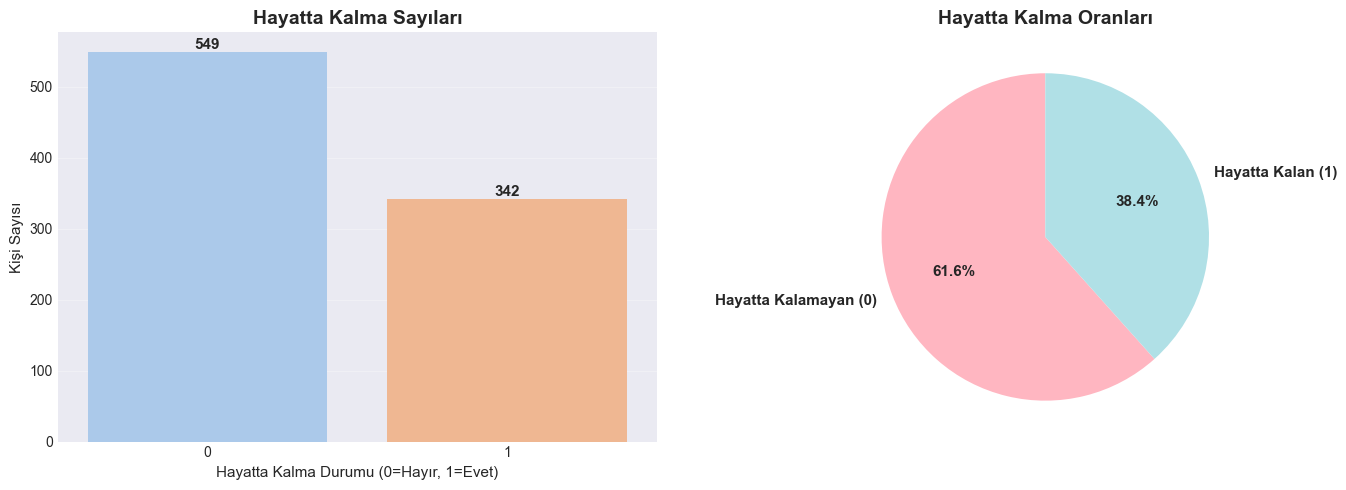

In [7]:
# Görselleştirme: Hayatta Kalma Dağılımı
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sol grafik: Count Plot (Sayı)
sns.countplot(data=df, x='survived', palette='pastel', ax=axes[0])
axes[0].set_title('Hayatta Kalma Sayıları', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Hayatta Kalma Durumu (0=Hayır, 1=Evet)', fontsize=11)
axes[0].set_ylabel('Kişi Sayısı', fontsize=11)
axes[0].grid(axis='y', alpha=0.3)

# Her bar'ın üzerine değerleri yazdır
for container in axes[0].containers:
    axes[0].bar_label(container, fontsize=11, fontweight='bold')

# Sağ grafik: Pie Chart (Yüzde)
colors_pastel = ['#FFB6C1', '#B0E0E6']
axes[1].pie(survival_counts, labels=['Hayatta Kalamayan (0)', 'Hayatta Kalan (1)'], 
            autopct='%1.1f%%', startangle=90, colors=colors_pastel,
            textprops={'fontsize': 11, 'fontweight': 'bold'})
axes[1].set_title('Hayatta Kalma Oranları', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### 👥 Kategorik Değişkenlerin Analizi

Kategorik değişkenlerimiz: **sex** (cinsiyet), **pclass** (yolcu sınıfı), **embarked** (biniş limanı)

**YBS açısından:** Bunlar segmentasyon değişkenleridir. Bir e-ticaret sitesinde müşteri segmentleri gibi.

In [8]:
# Kategorik değişkenlerin dağılımını inceleyelim
categorical_columns = ['sex', 'pclass', 'embarked', 'who', 'adult_male', 'alone']

print("📊 KATEGORİK DEĞİŞKENLERİN DAĞILIMI")
print("=" * 60)

for col in categorical_columns:
    print(f"\n🔹 {col.upper()}")
    print("-" * 60)
    value_counts = df[col].value_counts()
    print(value_counts)
    print(f"   Toplam benzersiz değer: {df[col].nunique()}")
    print(f"   Eksik değer sayısı: {df[col].isnull().sum()}")

📊 KATEGORİK DEĞİŞKENLERİN DAĞILIMI

🔹 SEX
------------------------------------------------------------
sex
male      577
female    314
Name: count, dtype: int64
   Toplam benzersiz değer: 2
   Eksik değer sayısı: 0

🔹 PCLASS
------------------------------------------------------------
pclass
3    491
1    216
2    184
Name: count, dtype: int64
   Toplam benzersiz değer: 3
   Eksik değer sayısı: 0

🔹 EMBARKED
------------------------------------------------------------
embarked
S    644
C    168
Q     77
Name: count, dtype: int64
   Toplam benzersiz değer: 3
   Eksik değer sayısı: 2

🔹 WHO
------------------------------------------------------------
who
man      537
woman    271
child     83
Name: count, dtype: int64
   Toplam benzersiz değer: 3
   Eksik değer sayısı: 0

🔹 ADULT_MALE
------------------------------------------------------------
adult_male
True     537
False    354
Name: count, dtype: int64
   Toplam benzersiz değer: 2
   Eksik değer sayısı: 0

🔹 ALONE
-------------------

### 🔬 Cinsiyet ve Sınıfa Göre Hayatta Kalma Analizi

**Kritik Soru:** Cinsiyet ve yolcu sınıfı hayatta kalmayı etkiliyor mu?

Bu soruyu sormak, YBS'de "hangi müşteri segmenti daha fazla satın alıyor?" sorusuna benzer.

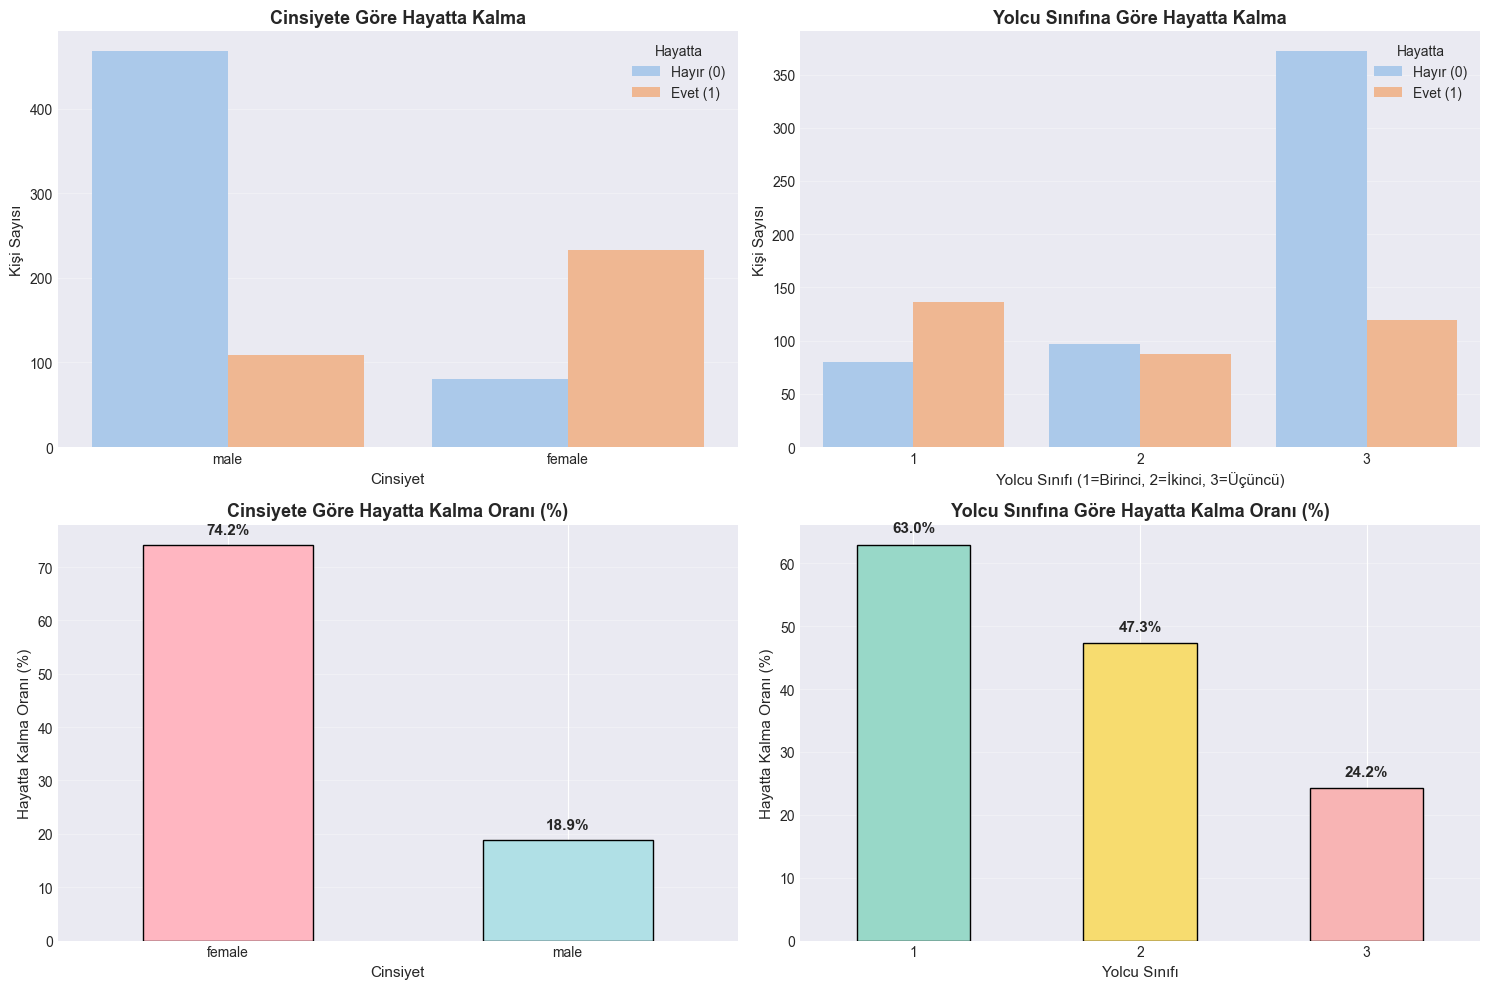


📊 HAKİKATLER
👩 Kadınların hayatta kalma oranı: 74.20%
👨 Erkeklerin hayatta kalma oranı: 18.89%

🎫 1. Sınıf yolcuların hayatta kalma oranı: 62.96%
🎫 2. Sınıf yolcuların hayatta kalma oranı: 47.28%
🎫 3. Sınıf yolcuların hayatta kalma oranı: 24.24%

💡 YORUM: Cinsiyet ve sosyoekonomik durum hayatta kalmada ÇOK ETKİLİ!
   Bu, YBS'de 'segmentasyon önemlidir' prensibinin kanıtıdır.


In [9]:
# Cinsiyet ve Sınıfa göre hayatta kalma görselleştirmesi
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Cinsiyet bazında hayatta kalma
sns.countplot(data=df, x='sex', hue='survived', palette='pastel', ax=axes[0, 0])
axes[0, 0].set_title('Cinsiyete Göre Hayatta Kalma', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Cinsiyet', fontsize=11)
axes[0, 0].set_ylabel('Kişi Sayısı', fontsize=11)
axes[0, 0].legend(title='Hayatta', labels=['Hayır (0)', 'Evet (1)'])
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. Yolcu sınıfına göre hayatta kalma
sns.countplot(data=df, x='pclass', hue='survived', palette='pastel', ax=axes[0, 1])
axes[0, 1].set_title('Yolcu Sınıfına Göre Hayatta Kalma', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Yolcu Sınıfı (1=Birinci, 2=İkinci, 3=Üçüncü)', fontsize=11)
axes[0, 1].set_ylabel('Kişi Sayısı', fontsize=11)
axes[0, 1].legend(title='Hayatta', labels=['Hayır (0)', 'Evet (1)'])
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. Cinsiyet bazında hayatta kalma yüzdesi
survival_by_sex = df.groupby('sex')['survived'].mean() * 100
survival_by_sex.plot(kind='bar', ax=axes[1, 0], color=['#FFB6C1', '#B0E0E6'], edgecolor='black')
axes[1, 0].set_title('Cinsiyete Göre Hayatta Kalma Oranı (%)', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Cinsiyet', fontsize=11)
axes[1, 0].set_ylabel('Hayatta Kalma Oranı (%)', fontsize=11)
axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=0)
axes[1, 0].grid(axis='y', alpha=0.3)

# Her bar'ın üzerine değerleri yazdır
for i, v in enumerate(survival_by_sex):
    axes[1, 0].text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=11)

# 4. Sınıf bazında hayatta kalma yüzdesi
survival_by_class = df.groupby('pclass')['survived'].mean() * 100
survival_by_class.plot(kind='bar', ax=axes[1, 1], color=['#98D8C8', '#F7DC6F', '#F8B4B4'], edgecolor='black')
axes[1, 1].set_title('Yolcu Sınıfına Göre Hayatta Kalma Oranı (%)', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Yolcu Sınıfı', fontsize=11)
axes[1, 1].set_ylabel('Hayatta Kalma Oranı (%)', fontsize=11)
axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=0)
axes[1, 1].grid(axis='y', alpha=0.3)

# Her bar'ın üzerine değerleri yazdır
for i, v in enumerate(survival_by_class):
    axes[1, 1].text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

# Sayısal özet
print("\n" + "=" * 60)
print("📊 HAKİKATLER")
print("=" * 60)
print(f"👩 Kadınların hayatta kalma oranı: {survival_by_sex['female']:.2f}%")
print(f"👨 Erkeklerin hayatta kalma oranı: {survival_by_sex['male']:.2f}%")
print(f"\n🎫 1. Sınıf yolcuların hayatta kalma oranı: {survival_by_class[1]:.2f}%")
print(f"🎫 2. Sınıf yolcuların hayatta kalma oranı: {survival_by_class[2]:.2f}%")
print(f"🎫 3. Sınıf yolcuların hayatta kalma oranı: {survival_by_class[3]:.2f}%")
print("=" * 60)
print("\n💡 YORUM: Cinsiyet ve sosyoekonomik durum hayatta kalmada ÇOK ETKİLİ!")
print("   Bu, YBS'de 'segmentasyon önemlidir' prensibinin kanıtıdır.")

### 👶👨👴 Yaş Dağılımı ve Analizi

**Yaş** çok önemli bir değişkendir ama içinde **eksik veri** var. Önce dağılımını inceleyelim.

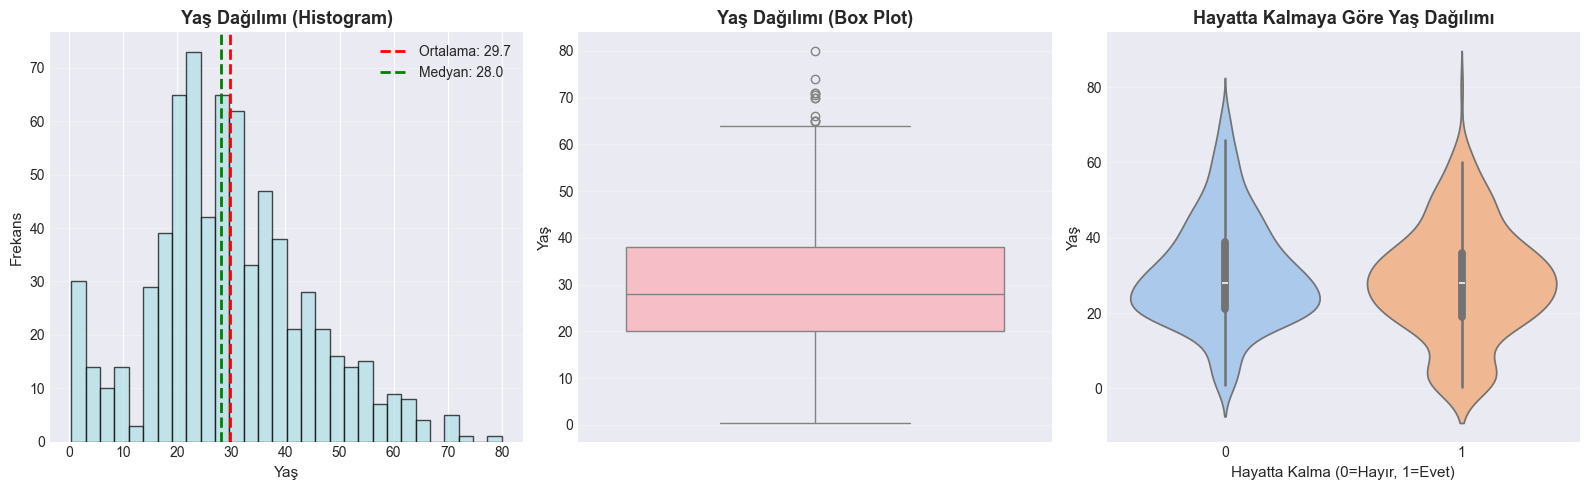


📊 YAŞ İSTATİSTİKLERİ
📈 Ortalama Yaş: 29.70
📊 Medyan Yaş: 28.00
📉 Standart Sapma: 14.53
👶 En Küçük Yaş: 0.42
👴 En Büyük Yaş: 80.00
⚠️ Eksik Değer Sayısı: 177 (19.9%)


In [10]:
# Yaş dağılımı görselleştirmesi
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Histogram - Yaş dağılımı
axes[0].hist(df['age'].dropna(), bins=30, color='#B0E0E6', edgecolor='black', alpha=0.7)
axes[0].set_title('Yaş Dağılımı (Histogram)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Yaş', fontsize=11)
axes[0].set_ylabel('Frekans', fontsize=11)
axes[0].axvline(df['age'].mean(), color='red', linestyle='--', linewidth=2, label=f'Ortalama: {df["age"].mean():.1f}')
axes[0].axvline(df['age'].median(), color='green', linestyle='--', linewidth=2, label=f'Medyan: {df["age"].median():.1f}')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# 2. Box Plot - Yaş dağılımı ve outlier tespiti
sns.boxplot(y=df['age'], color='#FFB6C1', ax=axes[1])
axes[1].set_title('Yaş Dağılımı (Box Plot)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Yaş', fontsize=11)
axes[1].grid(axis='y', alpha=0.3)

# 3. Hayatta kalmaya göre yaş dağılımı
sns.violinplot(data=df, x='survived', y='age', palette='pastel', ax=axes[2])
axes[2].set_title('Hayatta Kalmaya Göre Yaş Dağılımı', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Hayatta Kalma (0=Hayır, 1=Evet)', fontsize=11)
axes[2].set_ylabel('Yaş', fontsize=11)
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Yaş istatistikleri
print("\n" + "=" * 60)
print("📊 YAŞ İSTATİSTİKLERİ")
print("=" * 60)
print(f"📈 Ortalama Yaş: {df['age'].mean():.2f}")
print(f"📊 Medyan Yaş: {df['age'].median():.2f}")
print(f"📉 Standart Sapma: {df['age'].std():.2f}")
print(f"👶 En Küçük Yaş: {df['age'].min():.2f}")
print(f"👴 En Büyük Yaş: {df['age'].max():.2f}")
print(f"⚠️ Eksik Değer Sayısı: {df['age'].isnull().sum()} ({df['age'].isnull().sum() / len(df) * 100:.1f}%)")
print("=" * 60)

### 💰 Bilet Ücreti (Fare) Analizi

Bilet ücreti, yolcunun **sosyoekonomik durumunun** bir göstergesidir. YBS'de bu, müşterinin harcama gücüne benzer.

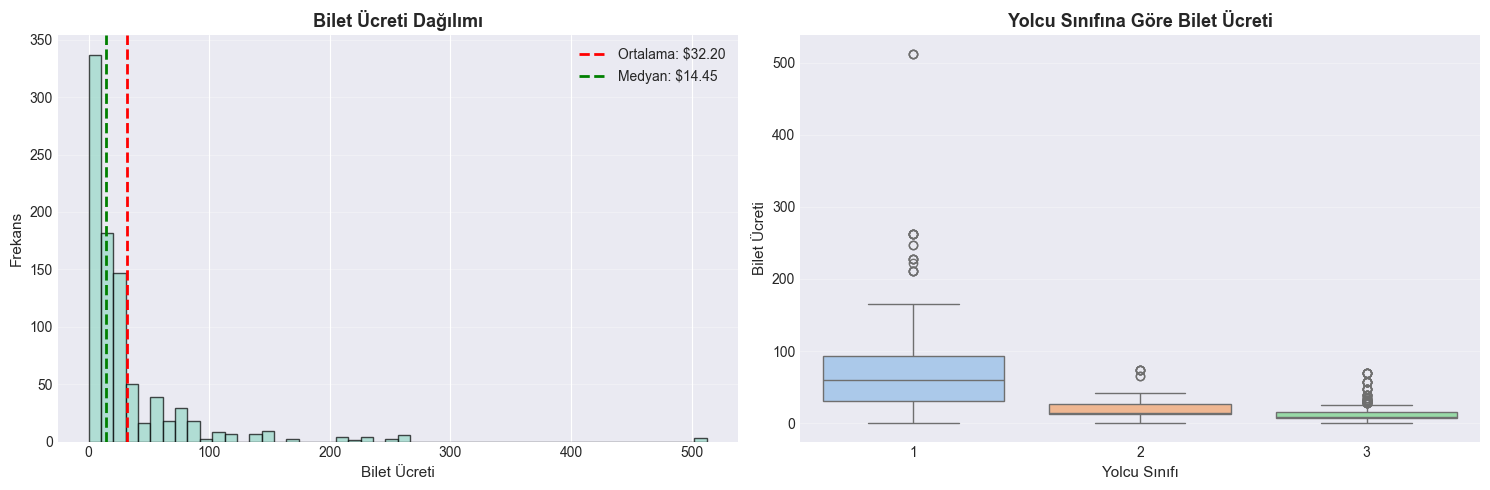


💰 SINIFA GÖRE ORTALAMA BİLET ÜCRETİ
🎫 1. Sınıf: $84.15
🎫 2. Sınıf: $20.66
🎫 3. Sınıf: $13.68

💡 YORUM: Bilet ücreti ile sınıf arasında çok güçlü ilişki var.
   Bu, 'multicollinearity' (çoklu bağlantı) örneğidir.


In [11]:
# Bilet ücreti analizi
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Bilet ücreti dağılımı (histogram)
axes[0].hist(df['fare'], bins=50, color='#98D8C8', edgecolor='black', alpha=0.7)
axes[0].set_title('Bilet Ücreti Dağılımı', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Bilet Ücreti', fontsize=11)
axes[0].set_ylabel('Frekans', fontsize=11)
axes[0].axvline(df['fare'].mean(), color='red', linestyle='--', linewidth=2, label=f'Ortalama: ${df["fare"].mean():.2f}')
axes[0].axvline(df['fare'].median(), color='green', linestyle='--', linewidth=2, label=f'Medyan: ${df["fare"].median():.2f}')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# 2. Sınıfa göre bilet ücreti
sns.boxplot(data=df, x='pclass', y='fare', palette='pastel', ax=axes[1])
axes[1].set_title('Yolcu Sınıfına Göre Bilet Ücreti', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Yolcu Sınıfı', fontsize=11)
axes[1].set_ylabel('Bilet Ücreti', fontsize=11)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Sınıfa göre ortalama bilet ücreti
print("\n" + "=" * 60)
print("💰 SINIFA GÖRE ORTALAMA BİLET ÜCRETİ")
print("=" * 60)
for pclass in [1, 2, 3]:
    avg_fare = df[df['pclass'] == pclass]['fare'].mean()
    print(f"🎫 {pclass}. Sınıf: ${avg_fare:.2f}")
print("=" * 60)
print("\n💡 YORUM: Bilet ücreti ile sınıf arasında çok güçlü ilişki var.")
print("   Bu, 'multicollinearity' (çoklu bağlantı) örneğidir.")

## 🧹 **ADIM 3: Eksik Veri Analizi - Tespit ve Ölçümleme**

**Şimdi işin özüne geliyoruz!** Eksik veriler gerçek hayatın bir parçasıdır. Bir veri bilimcinin en önemli becerilerinden biri, eksik verilerle **nasıl başa çıkacağını bilmektir**.

**YBS Perspektifi:** Bir şirkette CRM sisteminden veri çektiğinizde, müşteri adreslerinin %40'ı boş olabilir. Bu bilgiyi görmezden gelir misiniz, siler misiniz, yoksa doldurur musunuz? İşte bu karar, stratejik bir karardır.

### 📊 Tüm Kolonlarda Eksik Veri Tespiti

İlk adım: **Her kolonda kaç tane eksik veri var?**

In [12]:
# Her kolondaki eksik veri sayısını ve yüzdesini hesaplayalım
missing_data = pd.DataFrame({
    'Kolon': df.columns,
    'Eksik_Sayı': df.isnull().sum().values,
    'Eksik_Yüzde': (df.isnull().sum().values / len(df) * 100).round(2)
})

# Sadece eksik verisi olan kolonları göster ve yüzdeye göre sırala
missing_data = missing_data[missing_data['Eksik_Sayı'] > 0].sort_values('Eksik_Yüzde', ascending=False).reset_index(drop=True)

print("🔍 EKSİK VERİ ANALİZİ RAPORU")
print("=" * 70)
print(f"📦 Toplam Satır Sayısı: {len(df)}")
print(f"📋 Toplam Kolon Sayısı: {len(df.columns)}")
print(f"⚠️ Eksik Verisi Olan Kolon Sayısı: {len(missing_data)}")
print("=" * 70)
print("\n📊 Eksik Verilerin Detayı:")
print(missing_data.to_string(index=False))
print("=" * 70)

🔍 EKSİK VERİ ANALİZİ RAPORU
📦 Toplam Satır Sayısı: 891
📋 Toplam Kolon Sayısı: 15
⚠️ Eksik Verisi Olan Kolon Sayısı: 4

📊 Eksik Verilerin Detayı:
      Kolon  Eksik_Sayı  Eksik_Yüzde
       deck         688        77.22
        age         177        19.87
   embarked           2         0.22
embark_town           2         0.22


### 🎨 Eksik Veri Görselleştirmesi

Sayılar güzel ama **görsel daha etkili**. İki farklı grafik çizeceğiz:
1. **Bar Chart:** Eksik veri yüzdeleri
2. **Heatmap:** Hangi satırlarda eksik veri var?

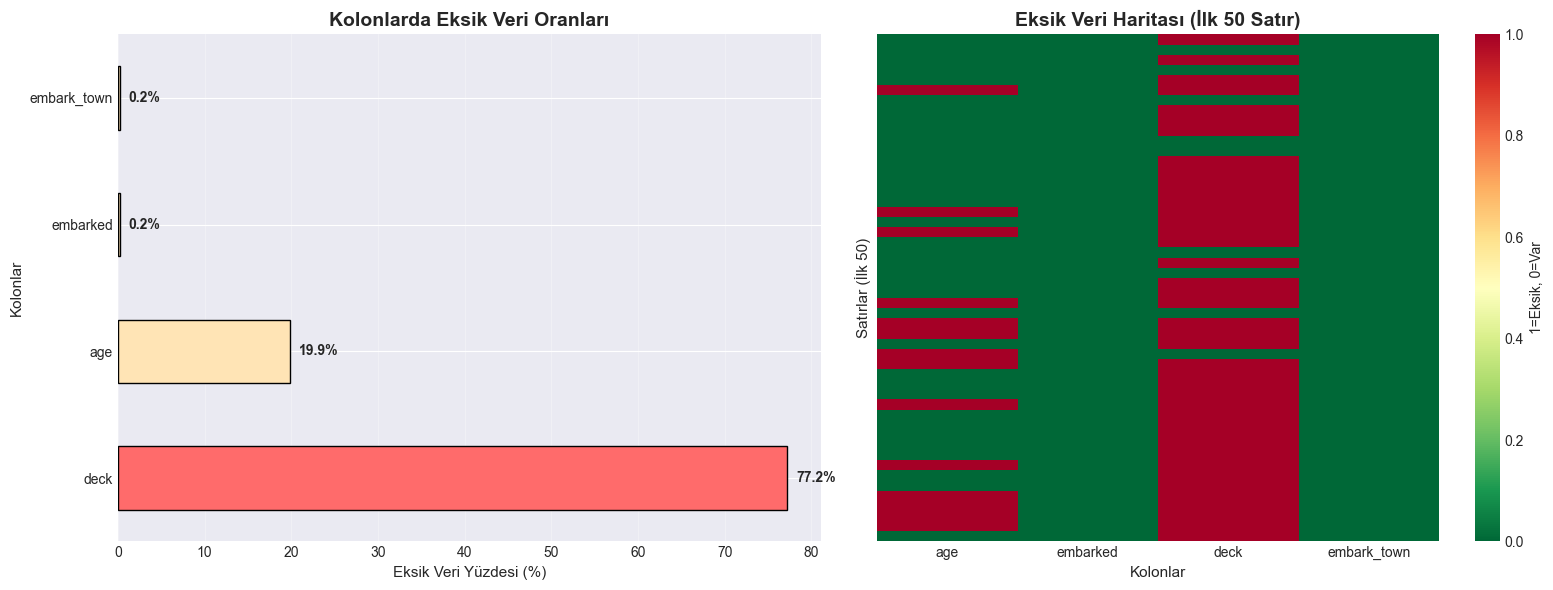


🎨 GRAFİK YORUMU
📍 KIRMIZI BARLAR (%50+): Bu kolonlar neredeyse kullanılamaz!
📍 TURUNCU BARLAR (%20-50): Dikkatli olmak gerekir.
📍 BEJ BARLAR (%0-20): Kolayca doldurulabilir.


In [13]:
# Eksik veri görselleştirmesi
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Bar Chart - Eksik Veri Yüzdeleri (en fazla olan 10 kolon)
missing_percent = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_percent_top = missing_percent[missing_percent > 0].head(10)

colors = ['#FF6B6B' if x > 50 else '#FFA07A' if x > 20 else '#FFE4B5' for x in missing_percent_top.values]
missing_percent_top.plot(kind='barh', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title('Kolonlarda Eksik Veri Oranları', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Eksik Veri Yüzdesi (%)', fontsize=11)
axes[0].set_ylabel('Kolonlar', fontsize=11)
axes[0].grid(axis='x', alpha=0.3)

# Yüzdeleri bar'ların üzerine yaz
for i, v in enumerate(missing_percent_top.values):
    axes[0].text(v + 1, i, f'{v:.1f}%', va='center', fontweight='bold', fontsize=10)

# 2. Heatmap - Eksik Veri Haritası (ilk 20 satır için)
# Sadece eksik verisi olan kolonları alalım
cols_with_missing = df.columns[df.isnull().any()].tolist()
axes[1].set_title('Eksik Veri Haritası (İlk 50 Satır)', fontsize=14, fontweight='bold')

# isnull() True/False döner, biz bunu 1/0'a çevirelim
missing_matrix = df[cols_with_missing].head(50).isnull().astype(int)
sns.heatmap(missing_matrix, cmap='RdYlGn_r', cbar=True, ax=axes[1], 
            yticklabels=False, cbar_kws={'label': '1=Eksik, 0=Var'})
axes[1].set_xlabel('Kolonlar', fontsize=11)
axes[1].set_ylabel('Satırlar (İlk 50)', fontsize=11)

plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("🎨 GRAFİK YORUMU")
print("=" * 70)
print("📍 KIRMIZI BARLAR (%50+): Bu kolonlar neredeyse kullanılamaz!")
print("📍 TURUNCU BARLAR (%20-50): Dikkatli olmak gerekir.")
print("📍 BEJ BARLAR (%0-20): Kolayca doldurulabilir.")
print("=" * 70)

### ⚖️ Kritik Karar Noktası: Hangi Kolon Ne Yapılmalı?

**Bu en kritik karardır!** Her kolonun eksik veri durumunu değerlendirip strateji belirlememiz gerekiyor.

```mermaid
graph TD
    A["🔍 Eksik Veri Var"] --> B{"Eksik Veri<br/>Oranı?"}
    
    B -->|"< %5"| C["✅ ÇOK İYİ<br/>Doldurulabilir"]
    B -->|"%5-20"| D["⚠️ İDARE EDİLİR<br/>Doldur ya da Sil"]
    B -->|"%20-60"| E["🤔 RİSKLİ<br/>Analiz Et"]
    B -->|"> %60"| F["❌ KULLANILMAZ<br/>Kolonü Sil"]
    
    C --> G["İmputation Yöntemleri<br/>- Ortalama/Medyan<br/>- Mod<br/>- Forward/Backward Fill"]
    
    D --> H{"Kolon<br/>Önemli mi?"}
    H -->|"Evet"| G
    H -->|"Hayır"| I["Kolonü Sil"]
    
    E --> J{"Eksiklik<br/>Rastgele mi?"}
    J -->|"Evet (MAR/MCAR)"| G
    J -->|"Hayır (MNAR)"| K["Özel Analiz<br/>Gerekli"]
    
    F --> I
    
    style A fill:#E8F5E9,stroke:#66BB6A,stroke-width:3px,color:#000
    style C fill:#C8E6C9,stroke:#66BB6A,stroke-width:2px,color:#000
    style D fill:#FFF9C4,stroke:#FDD835,stroke-width:2px,color:#000
    style E fill:#FFE0B2,stroke:#FF9800,stroke-width:2px,color:#000
    style F fill:#FFCDD2,stroke:#F44336,stroke-width:2px,color:#000
    style G fill:#B3E5FC,stroke:#03A9F4,stroke-width:2px,color:#000
    style I fill:#FFCDD2,stroke:#F44336,stroke-width:2px,color:#000
```

**YBS Açısından:** Bu karar ağacı, iş dünyasında "hangi müşteri verisi eksikse ne yaparız?" sorusunun sistematik cevabıdır.

### 📋 Titanic Veri Seti için Stratejik Kararlar

Her kolon için **bilinçli bir karar** verelim:

In [14]:
# Her kolon için stratejik karar tablosu oluşturalım
strategy_decisions = []

for col in df.columns:
    missing_count = df[col].isnull().sum()
    missing_percent = (missing_count / len(df)) * 100
    
    if missing_count == 0:
        decision = "✅ Eksik Yok"
        action = "-"
        reason = "Temiz veri"
    elif missing_percent > 70:
        decision = "❌ SİL"
        action = "Kolonü komple sil"
        reason = f"%{missing_percent:.1f} eksik - kullanılamaz"
    elif missing_percent > 40:
        decision = "🤔 DEĞERLENDİR"
        action = "Kullanma ihtimali düşük"
        reason = f"%{missing_percent:.1f} eksik - riskli"
    elif missing_percent > 10:
        decision = "⚠️ DOLDUR"
        action = "İmputation gerekli"
        reason = f"%{missing_percent:.1f} eksik - doldurulabilir"
    else:
        decision = "✅ DOLDUR"
        action = "Kolay doldurulur"
        reason = f"Sadece %{missing_percent:.1f} eksik"
    
    strategy_decisions.append({
        'Kolon': col,
        'Eksik_Sayı': missing_count,
        'Eksik_%': round(missing_percent, 2),
        'Karar': decision,
        'Aksiyon': action,
        'Gerekçe': reason
    })

strategy_df = pd.DataFrame(strategy_decisions)

# Sadece aksiyona ihtiyacı olanları göster
action_needed = strategy_df[strategy_df['Eksik_Sayı'] > 0].sort_values('Eksik_%', ascending=False)

print("📋 STRATEJİK KARAR TABLOSU")
print("=" * 100)
print(action_needed[['Kolon', 'Eksik_%', 'Karar', 'Aksiyon']].to_string(index=False))
print("=" * 100)

# Özet istatistik
print("\n📊 ÖZET")
print("=" * 100)
print(f"❌ Silinmesi Gereken Kolonlar: {len(strategy_df[strategy_df['Karar'] == '❌ SİL'])}")
print(f"⚠️ Doldurulması Gereken Kolonlar: {len(strategy_df[strategy_df['Karar'].str.contains('DOLDUR')])}")
print(f"✅ Temiz Kolonlar: {len(strategy_df[strategy_df['Karar'] == '✅ Eksik Yok'])}")
print("=" * 100)

📋 STRATEJİK KARAR TABLOSU
      Kolon  Eksik_%     Karar            Aksiyon
       deck    77.22     ❌ SİL  Kolonü komple sil
        age    19.87 ⚠️ DOLDUR İmputation gerekli
   embarked     0.22  ✅ DOLDUR   Kolay doldurulur
embark_town     0.22  ✅ DOLDUR   Kolay doldurulur

📊 ÖZET
❌ Silinmesi Gereken Kolonlar: 1
⚠️ Doldurulması Gereken Kolonlar: 3
✅ Temiz Kolonlar: 11


### ✂️ Gereksiz Kolonları Silme

**Karar 1:** %70'in üzerinde eksik verisi olan kolonları silmeliyiz. Ayrıca, **tekrar eden** (duplicate) bilgileri içeren kolonları da temizleyelim.

**YBS Mantığı:** Bir raporda aynı bilgiyi 3 farklı şekilde göstermenin anlamı yoktur. Bu, veri setinde gereksiz ağırlık yaratır.

In [15]:
# Önce veri setinin bir kopyasını alalım
df_cleaned = df.copy()

print("🔍 ÖNCESİ DURUM")
print("=" * 70)
print(f"Satır sayısı: {df_cleaned.shape[0]}")
print(f"Kolon sayısı: {df_cleaned.shape[1]}")
print(f"Kolonlar: {list(df_cleaned.columns)}")

# Silinecek kolonları belirleyelim:
# 1. Çok fazla eksik veri olanlar: deck (%77 eksik), age (%20 eksik ama bunu dolduracağız)
# 2. Tekrar bilgi: who (sex ve age'den türetilebilir), adult_male, alive (survived'ın kopyası), 
#                   class (pclass'ın kopyası), embark_town (embarked'ın kopyası)

columns_to_drop = ['deck', 'who', 'adult_male', 'alive', 'class', 'embark_town']

print(f"\n✂️ SİLİNECEK KOLONLAR:")
for col in columns_to_drop:
    missing_pct = df_cleaned[col].isnull().sum() / len(df_cleaned) * 100
    print(f"   - {col}: %{missing_pct:.1f} eksik veri")

# Kolonları sil
df_cleaned = df_cleaned.drop(columns=columns_to_drop)

print(f"\n✅ SONRASI DURUM")
print("=" * 70)
print(f"Satır sayısı: {df_cleaned.shape[0]} (değişmedi ✓)")
print(f"Kolon sayısı: {df_cleaned.shape[1]} ({len(columns_to_drop)} kolon silindi)")
print(f"Kalan kolonlar: {list(df_cleaned.columns)}")
print("=" * 70)

print("\n💡 YBS Perspektifi:")
print("   Veri temizliği, bir şirketin veritabanını optimize etmeye benzer.")
print("   Gereksiz alanları silmek, hem performansı artırır hem karmaşıklığı azaltır.")

🔍 ÖNCESİ DURUM
Satır sayısı: 891
Kolon sayısı: 15
Kolonlar: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']

✂️ SİLİNECEK KOLONLAR:
   - deck: %77.2 eksik veri
   - who: %0.0 eksik veri
   - adult_male: %0.0 eksik veri
   - alive: %0.0 eksik veri
   - class: %0.0 eksik veri
   - embark_town: %0.2 eksik veri

✅ SONRASI DURUM
Satır sayısı: 891 (değişmedi ✓)
Kolon sayısı: 9 (6 kolon silindi)
Kalan kolonlar: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'alone']

💡 YBS Perspektifi:
   Veri temizliği, bir şirketin veritabanını optimize etmeye benzer.
   Gereksiz alanları silmek, hem performansı artırır hem karmaşıklığı azaltır.


### 🔎 Temizlenmiş Veri Setinin Son Durum Kontrolü

Gereksiz kolonları sildik. Şimdi **hangi kolonlarda hala eksik veri var** kontrol edelim.

In [16]:
# Temizlenmiş veri setindeki eksik verileri kontrol edelim
missing_after_cleaning = pd.DataFrame({
    'Kolon': df_cleaned.columns,
    'Eksik_Sayı': df_cleaned.isnull().sum().values,
    'Eksik_%': (df_cleaned.isnull().sum().values / len(df_cleaned) * 100).round(2)
})

# Sadece eksik verisi olanları göster
missing_after_cleaning = missing_after_cleaning[missing_after_cleaning['Eksik_Sayı'] > 0].sort_values('Eksik_%', ascending=False)

print("📊 TEMİZLENMİŞ VERİ SETİNDE KALAN EKSİK VERİLER")
print("=" * 70)
if len(missing_after_cleaning) > 0:
    print(missing_after_cleaning.to_string(index=False))
    print("=" * 70)
    print(f"\n📌 Doldurulması gereken {len(missing_after_cleaning)} kolon var:")
    for idx, row in missing_after_cleaning.iterrows():
        print(f"   • {row['Kolon']}: {row['Eksik_Sayı']} eksik (%{row['Eksik_%']})")
else:
    print("✅ HİÇ EKSİK VERİ YOK!")
print("=" * 70)

# Veri setinin genel durumu
print("\n📋 VERİ SETİ ÖZET BİLGİ")
print("=" * 70)
df_cleaned.info()
print("=" * 70)

📊 TEMİZLENMİŞ VERİ SETİNDE KALAN EKSİK VERİLER
   Kolon  Eksik_Sayı  Eksik_%
     age         177    19.87
embarked           2     0.22

📌 Doldurulması gereken 2 kolon var:
   • age: 177 eksik (%19.87)
   • embarked: 2 eksik (%0.22)

📋 VERİ SETİ ÖZET BİLGİ
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    object 
 3   age       714 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  889 non-null    object 
 8   alone     891 non-null    bool   
dtypes: bool(1), float64(2), int64(4), object(2)
memory usage: 56.7+ KB


## 📚 **ADIM 4: Missing Data Tipleri - Teorik Çerçeve**

**Bu kısım çok kritik!** Eksik verilerin neden eksik olduğunu bilmek, nasıl doldurmanız gerektiğini belirler.

İstatistikte eksik veriler **3 temel kategoriye** ayrılır. Bu sınıflandırma, Donald Rubin tarafından 1976'da yapılmıştır ve hala günceldir.

**YBS Perspektifi:** Bir müşteri anketinde bazı soruların cevapsız kalmasının nedeni, hangi stratejiyi uygulayacağınızı belirler. Bu, iş kararlarınızın doğruluğunu etkiler!

### 1️⃣ **MCAR - Missing Completely At Random (Tamamen Rastgele Eksik)**

**Tanım:** Verinin eksik olması hiçbir değişkenle ilişkili değildir. Tamamen şansa bağlıdır.

**Örnek Senaryolar:**
- 📝 Anket sırasında bir sayfa yanlışlıkla atlanır
- 💻 Veri girişi sırasında klavye bozulur, bazı satırlar kaydedilmez
- 🚢 Titanic'te: Bir form rüzgarla uçar, birtakım bilgiler kaybolur

**İstatistiksel Özellik:**
- Eksiklik, gözlemlenen ya da gözlemlenmeyen hiçbir değişkenle ilişkili değildir
- `P(Eksik | Tüm Veriler) = P(Eksik)` → Eksiklik tamamen rastgeledir

**YBS Açısından:**
- ✅ **İyi Haber:** En az sorunlu durumdur
- ✅ Basit yöntemlerle doldurulabilir (ortalama, medyan)
- ✅ Sonuçları sistematik olarak bozmaz
- ⚠️ Ama veri kaybı olduğu için istatistiksel güç azalır

**Gerçek Hayat:** Çok nadir görülür. Çoğu eksikliğin bir nedeni vardır!

### 2️⃣ **MAR - Missing At Random (Rastgele Eksik)**

**Tanım:** Verinin eksik olması, **başka bir gözlemlenen değişkenle** ilişkilidir ama eksik olan değerin kendisiyle değil.

**Örnek Senaryolar:**
- 👨 Erkekler kilo bilgisini paylaşmaktan çekiniyor (cinsiyet biliniyor ama kilo bilgisi eksik)
- 🎓 Düşük gelirli kişiler maaş bilgisini daha az paylaşıyor (gelir grubu biliniyor ama tam maaş eksik)
- 🚢 Titanic'te: 3. sınıf yolcuların kayıtları daha eksik (sınıf bilgisi var ama yaş eksik)

**İstatistiksel Özellik:**
- Eksiklik, **gözlemlenen** başka değişkenlerle açıklanabilir
- `P(Eksik | Gözlemlenen, Eksik) = P(Eksik | Gözlemlenen)`
- Eksiklik, eksik olan değerin kendisine bağlı değildir

**YBS Açısından:**
- ⚠️ **Dikkat:** Basit yöntemler yanlı (biased) sonuçlar verebilir
- ✅ Ama gözlemlenen değişkenleri kullanarak daha iyi tahmin yapılabilir
- 📊 Örnek: Cinsiyet ve sınıf bilgisini kullanarak yaşı tahmin edebiliriz
- 💡 İleri seviye imputation yöntemleri (KNN, MICE) burada çok etkilidir

**Gerçek Hayat:** En sık karşılaşılan durumdur!

### 3️⃣ **MNAR - Missing Not At Random (Rastgele Olmayan Eksik)**

**Tanım:** Verinin eksik olması, **eksik olan değerin kendisiyle** ilişkilidir. Yani eksiklik bilinçlidir ve sistematiktir.

**Örnek Senaryolar:**
- 💰 Çok yüksek geliri olanlar, gelir bilgisini özellikle gizler
- ⚖️ Kilolu insanlar tartı sorusunu atlar
- 😞 Depresyon testi yapan, depresyonlu kişiler testi yarıda bırakır
- 🚢 Titanic'te: Belki de çok yaşlı olanların bilgileri eksiktir çünkü kayıt zordu

**İstatistiksel Özellik:**
- Eksiklik, **eksik olan değerin kendisiyle** ilişkilidir
- `P(Eksik | Gözlemlenen, Eksik)` eksik değere bağlıdır
- Bu, tespit edilmesi en zor durumdur çünkü eksik olan değeri bilmiyoruz!

**YBS Açısından:**
- ❌ **ÇOK TEHLİKELİ:** En problemli durumdur
- ❌ Basit yöntemler ciddi **yanlı (biased)** sonuçlar verir
- ❌ Ortalama, medyan gibi yöntemler yanıltıcı olur
- 🔬 Özel modelleme teknikleri gerekir (Selection Models, Pattern Mixture Models)
- 🎯 Ya da eksikliği bir özellik olarak kullanmak gerekebilir

**Gerçek Hayat:** Tespit edilmesi çok zordur ama çok yaygındır!

### 📊 Üç Tipin Karşılaştırması

| Özellik | MCAR | MAR | MNAR |
|---------|------|-----|------|
| **Eksiklik Nedeni** | Tamamen rastgele | Başka değişkenle ilişkili | Değerin kendisiyle ilişkili |
| **Tehlike Derecesi** | 🟢 Düşük | 🟡 Orta | 🔴 Yüksek |
| **Tespit Zorluğu** | Kolay | Orta | Çok Zor |
| **Basit İmputation** | ✅ Güvenli | ⚠️ Dikkatli | ❌ Tehlikeli |
| **Çözüm Yolu** | Ortalama/Medyan | KNN, MICE, Regresyon | Özel Modelleme |
| **YBS Riski** | Düşük | Orta - Kontrol edilebilir | Yüksek - Kararlar yanıltıcı olabilir |

### 🎨 Görsel Özet: Eksik Veri Tipleri

```mermaid
graph TB
    A["🔍 EKSİK VERİ TESPİT EDİLDİ"] --> B{"Eksikliğin<br/>Nedeni Nedir?"}
    
    B -->|"Tamamen<br/>Şansa Bağlı"| C["MCAR<br/>Missing Completely<br/>At Random"]
    B -->|"Başka Değişkenle<br/>İlişkili"| D["MAR<br/>Missing At Random"]
    B -->|"Değerin Kendisiyle<br/>İlişkili"| E["MNAR<br/>Missing Not<br/>At Random"]
    
    C --> C1["Örnek:<br/>Form uçtu,<br/>veri girilmedi"]
    C1 --> C2["✅ Kolay Çözüm:<br/>Ortalama/Medyan"]
    C2 --> C3["🟢 Risk: DÜŞÜK"]
    
    D --> D1["Örnek:<br/>Erkekler kilo<br/>paylaşmıyor"]
    D1 --> D2["⚠️ Dikkatli Çözüm:<br/>KNN, MICE,<br/>Regresyon"]
    D2 --> D3["🟡 Risk: ORTA"]
    
    E --> E1["Örnek:<br/>Zenginler gelir<br/>gizliyor"]
    E1 --> E2["❌ Zor Çözüm:<br/>Özel Modelleme<br/>gerekli"]
    E2 --> E3["🔴 Risk: YÜKSEK"]
    
    style A fill:#E8F5E9,stroke:#66BB6A,stroke-width:3px,color:#000
    style B fill:#FFF9C4,stroke:#FDD835,stroke-width:3px,color:#000
    
    style C fill:#C8E6C9,stroke:#66BB6A,stroke-width:2px,color:#000
    style C1 fill:#E8F5E9,stroke:#81C784,stroke-width:2px,color:#000
    style C2 fill:#E8F5E9,stroke:#81C784,stroke-width:2px,color:#000
    style C3 fill:#C8E6C9,stroke:#66BB6A,stroke-width:3px,color:#000
    
    style D fill:#FFE082,stroke:#FFB300,stroke-width:2px,color:#000
    style D1 fill:#FFF9C4,stroke:#FDD835,stroke-width:2px,color:#000
    style D2 fill:#FFF9C4,stroke:#FDD835,stroke-width:2px,color:#000
    style D3 fill:#FFE082,stroke:#FFB300,stroke-width:3px,color:#000
    
    style E fill:#FFCCBC,stroke:#FF6B6B,stroke-width:2px,color:#000
    style E1 fill:#FFE0B2,stroke:#FF9800,stroke-width:2px,color:#000
    style E2 fill:#FFE0B2,stroke:#FF9800,stroke-width:2px,color:#000
    style E3 fill:#FFCCBC,stroke:#FF6B6B,stroke-width:3px,color:#000
```

### 🚢 Titanic Veri Setinde Eksik Veri Tipleri Analizi

Şimdi **kendi veri setimize** bakalım. Eksik verilerimiz hangi kategoriye giriyor?

In [17]:
# Temizlenmiş veri setindeki eksik kolonları analiz edelim: age ve embarked
print("🔬 TİTANİC VERİ SETİNDE EKSİK VERİ TİPİ ANALİZİ")
print("=" * 80)

# 1. AGE (Yaş) Analizi
print("\n📊 1. AGE (YAŞ) KOLONUNDAKİ EKSİKLİK ANALİZİ")
print("-" * 80)

# Yaşı eksik olanlar ile olmayanları karşılaştıralım
age_missing = df_cleaned[df_cleaned['age'].isnull()]
age_not_missing = df_cleaned[df_cleaned['age'].notnull()]

print(f"Yaşı eksik olan yolcu sayısı: {len(age_missing)}")
print(f"Yaşı olan yolcu sayısı: {len(age_not_missing)}")

# Cinsiyet dağılımı
print(f"\n👥 Cinsiyet Dağılımı:")
print(f"   Yaşı EKSIK olanlarda kadın oranı: {(age_missing['sex'] == 'female').sum() / len(age_missing) * 100:.1f}%")
print(f"   Yaşı OLAN olanlarda kadın oranı: {(age_not_missing['sex'] == 'female').sum() / len(age_not_missing) * 100:.1f}%")

# Sınıf dağılımı
print(f"\n🎫 Sınıf Dağılımı:")
for pclass in [1, 2, 3]:
    missing_pct = (age_missing['pclass'] == pclass).sum() / len(age_missing) * 100
    not_missing_pct = (age_not_missing['pclass'] == pclass).sum() / len(age_not_missing) * 100
    print(f"   {pclass}. Sınıf - Yaşı EKSIK: %{missing_pct:.1f} | Yaşı OLAN: %{not_missing_pct:.1f}")

# Hayatta kalma oranı
survival_missing = age_missing['survived'].mean() * 100
survival_not_missing = age_not_missing['survived'].mean() * 100
print(f"\n💚 Hayatta Kalma Oranı:")
print(f"   Yaşı EKSIK olanlar: %{survival_missing:.1f}")
print(f"   Yaşı OLAN olanlar: %{survival_not_missing:.1f}")

print(f"\n🔍 DEĞERLENDİRME:")
print(f"   Yaş eksikliği sınıfla ilişkili görünüyor (3. sınıfta daha fazla eksik).")
print(f"   Bu durum MAR (Missing At Random) olabilir.")
print(f"   Yani: Sınıf bilgisini kullanarak yaşı tahmin edebiliriz!")

# 2. EMBARKED (Biniş Limanı) Analizi
print("\n" + "=" * 80)
print("\n📊 2. EMBARKED (BİNİŞ LİMANI) KOLONUNDAKİ EKSİKLİK ANALİZİ")
print("-" * 80)

embarked_missing = df_cleaned[df_cleaned['embarked'].isnull()]
print(f"Embarked eksik olan yolcu sayısı: {len(embarked_missing)}")
print(f"\nBu sadece {len(embarked_missing)} kişi! Çok az.")
print(f"Bu durum büyük ihtimalle MCAR (tamamen rastgele) olabilir.")
print(f"Basit imputation (mod ile doldurma) yeterli olur.")

print("\n" + "=" * 80)

🔬 TİTANİC VERİ SETİNDE EKSİK VERİ TİPİ ANALİZİ

📊 1. AGE (YAŞ) KOLONUNDAKİ EKSİKLİK ANALİZİ
--------------------------------------------------------------------------------
Yaşı eksik olan yolcu sayısı: 177
Yaşı olan yolcu sayısı: 714

👥 Cinsiyet Dağılımı:
   Yaşı EKSIK olanlarda kadın oranı: 29.9%
   Yaşı OLAN olanlarda kadın oranı: 36.6%

🎫 Sınıf Dağılımı:
   1. Sınıf - Yaşı EKSIK: %16.9 | Yaşı OLAN: %26.1
   2. Sınıf - Yaşı EKSIK: %6.2 | Yaşı OLAN: %24.2
   3. Sınıf - Yaşı EKSIK: %76.8 | Yaşı OLAN: %49.7

💚 Hayatta Kalma Oranı:
   Yaşı EKSIK olanlar: %29.4
   Yaşı OLAN olanlar: %40.6

🔍 DEĞERLENDİRME:
   Yaş eksikliği sınıfla ilişkili görünüyor (3. sınıfta daha fazla eksik).
   Bu durum MAR (Missing At Random) olabilir.
   Yani: Sınıf bilgisini kullanarak yaşı tahmin edebiliriz!


📊 2. EMBARKED (BİNİŞ LİMANI) KOLONUNDAKİ EKSİKLİK ANALİZİ
--------------------------------------------------------------------------------
Embarked eksik olan yolcu sayısı: 2

Bu sadece 2 kişi! Çok az.
Bu 

### 💼 **YBS Perspektifinden Eksik Veri Tipleri - İş Dünyası Örnekleri**

Bu teorik bilgi sadece akademik değil, **iş kararlarınızı doğrudan etkiler**!

| Senaryo | Eksiklik Tipi | Risk | Strateji |
|---------|---------------|------|----------|
| **Müşteri Anketi** - Sayfa yanlışlıkla atlandı | MCAR | 🟢 Düşük | Basit doldurma |
| **E-ticaret** - Genç kullanıcılar adres paylaşmıyor | MAR | 🟡 Orta | Yaş grubuna göre tahmin |
| **İK Veritabanı** - Yüksek maaşlılar maaş gizliyor | MNAR | 🔴 Yüksek | Özel analiz, eksikliği feature yap |
| **CRM** - Düşük gelirli müşteriler gelir yazmıyor | MNAR | 🔴 Yüksek | Harcama verisiyle ilişkilendir |
| **Sağlık** - Yaşlılar sağlık bilgisi vermiyor | MNAR | 🔴 Yüksek | Çok dikkatli imputation |

**🎯 Ana Mesaj:**
> Eksik verinin **neden** eksik olduğunu anlamadan doldurma yaparsanız, yanlış iş kararları üretirsiniz!

**Örnek:**
- Eğer zengin müşteriler gelir bilgisini gizliyor ve siz ortalama ile doldurursanız → Müşteri profilinizi yanlış çıkarırsınız
- Eğer yaşlılar yaş bilgisini vermiyor ve siz medyan ile doldurursanız → Yaşlı müşteri stratejiniz başarısız olur

**Bu yüzden:**
1. ✅ Önce eksikliğin nedenini araştırın
2. ✅ Diğer değişkenlerle ilişkisini kontrol edin
3. ✅ Gerekirse eksikliği bir özellik olarak kullanın ("yaş_eksik" gibi)
4. ✅ İki farklı yöntemle doldurup sonuçları karşılaştırın

## ⚖️ **ADIM 5: Eksik Veri Stratejileri - Ne Yapmalı?**

Artık eksik veri tiplerini biliyoruz. Şimdi **ne yapacağız?** sorusuna geliyoruz.

Elimizde **3 temel seçenek** var:
1. **🗑️ Silme** (Deletion)
2. **🔧 Doldurma** (Imputation) 
3. **🎯 Eksikliği Özellik Olarak Kullanma**

**YBS Perspektifi:** Bir CRM veritabanında eksik müşteri bilgisi varsa, o müşteriyi siler misiniz? Bilgiyi tahmin eder misiniz? Yoksa eksikliği bir özellik olarak mı kullanırsınız? Bu karar, stratejinizi belirler!

### 🗑️ **Strateji 1: SİLME (Deletion)**

**Ne Yapılır:** Eksik veri içeren satırları veya kolonları komple sileriz.

**İki Alt Yöntem:**
1. **Listwise Deletion (Satır Silme):** Eksik veri içeren tüm satırı sil
2. **Columnwise Deletion (Kolon Silme):** Eksik veri çok fazla olan kolonu sil

| Özellik | Listwise (Satır) | Columnwise (Kolon) |
|---------|------------------|---------------------|
| **Ne Siler** | Eksik veri içeren satırlar | Eksik veri çok olan kolonlar |
| **Ne Zaman** | Çok az satırda eksik var | %70+ eksik veri var |
| **Avantaj** | ✅ Çok hızlı ve basit<br/>✅ Temiz veri kalır | ✅ Veri boyutunu azaltır<br/>✅ Problemli özellikleri elener |
| **Dezavantaj** | ❌ Veri kaybı çok olabilir<br/>❌ Bilgi kaybı | ❌ Önemli değişken kaybedilebilir |
| **Risk** | 🟡 MCAR'da güvenli, MAR/MNAR'da riskli | 🟢 Genelde güvenli |

**YBS Örneği:**
- **Satır Silme:** 10,000 müşteriden 50'sinin adresi eksik → O 50 müşteriyi sil
- **Kolon Silme:** Müşterilerin %80'inin "2. tel no" bilgisi yok → O kolonu sil

**Ne Zaman Kullanılır:**
- ✅ Eksik veri %5'ten az ise
- ✅ Eksiklik MCAR tipindeyse  
- ✅ Hala yeterli veri kalıyorsa

**Ne Zaman Kullanılmaz:**
- ❌ Eksik veri MAR veya MNAR ise (yanlı sonuçlar)
- ❌ Veri zaten az ise
- ❌ Eksik veri belirli bir gruba (örn: yaşlılar) özgüyse

### 🔧 **Strateji 2: DOLDURMA (Imputation)**

**Ne Yapılır:** Eksik değerleri tahmin edilen değerlerle doldururuz

**Sayısal Değişkenler İçin Yöntemler:**

| Yöntem | Nasıl Yapılır | Ne Zaman Kullanılır | Avantaj/Dezavantaj |
|--------|---------------|---------------------|---------------------|
| **Ortalama** | Kolonun ortalamasını koy | Dağılım simetrik, outlier yok | ✅ Hızlı ❌ Varyansı azaltır |
| **Medyan** | Kolonun medyanını koy | Outlier var, çarpık dağılım | ✅ Outlier'a dayanıklı ❌ Bilgi kaybı |
| **Mod** | En sık değeri koy | Kategorik veya ayrık sayısal | ✅ Basit ❌ Çok varyans kaybı |
| **Forward Fill** | Önceki değeri taşı | Zaman serisi verisi | ✅ Mantıklı sıra ❌ Veri sıralı olmalı |
| **Backward Fill** | Sonraki değeri taşı | Zaman serisi verisi | ✅ Geleceğe bakış ❌ Veri sıralı olmalı |
| **KNN** | K yakın komşunun ortalaması | MAR tipi eksiklik | ✅ Akıllı ❌ Yavaş |
| **Regresyon** | Diğer kolonlardan tahmin | Güçlü ilişkiler var | ✅ Çok doğru ❌ Karmaşık |
| **MICE** | Multiple Imputation | MAR, birden fazla eksik kolon | ✅ En doğru ❌ Çok yavaş |

**Kategorik Değişkenler İçin:**
- **Mod (En Sık):** En basit ve en yaygın
- **Yeni Kategori:** "Unknown" kategorisi ekle
- **Model Tabanlı:** Classification modeli kur

**YBS Örneği:**
- **Ortalama:** Müşteri yaşı eksik → Ortalama 35 yaş koy
- **Medyan:** Maaş bilgisi eksik, 1-2 çok yüksek maaş var → Medyan kullan
- **Mod:** Şehir bilgisi eksik → En sık şehir "İstanbul" koy
- **KNN:** Benzer profilli müşterilerin yaşına bak

### 🎯 **Strateji 3: EKSİKLİĞİ ÖZELLİK OLARAK KULLANMA**

**Ne Yapılır:** Eksikliğin kendisini bir bilgi olarak kullanırız!

**Nasıl:**
- Yeni bir **binary (0/1) kolon** oluştur
- Örnek: `age_missing` = 1 (yaş eksik), 0 (yaş var)
- Sonra orijinal kolonu doldur (ortalama/medyan ile)

**Ne Zaman Kullanılır:**
- Eksiklik **MNAR** tipindeyse (yani eksikliğin kendisi anlamlıysa)
- Eksiklik belirli bir özellik gösteriyorsa
- Model performansını artırabilir

**YBS Örneği:**
| Senaryo | Neden Önemli | Nasıl Kullanılır |
|---------|--------------|------------------|
| **Gelir bilgisi eksik** | Zenginler gizliyor olabilir | `income_missing` = 1 → Yüksek gelir sinyali |
| **Sağlık verisi eksik** | Hasta olanlar doldurmamış olabilir | `health_missing` = 1 → Risk faktörü |
| **Yaş bilgisi eksik** | Yaşlılar vermemiş olabilir | `age_missing` = 1 → Yaş grubu göstergesi |

**Avantajlar:**
- ✅ Bilgi kaybı yok - hem doldur hem eksikliği tut
- ✅ MNAR durumunda çok değerli
- ✅ Modelin eksikliği öğrenmesine izin verir

**Dezavantajlar:**
- ❌ Ekstra kolon = daha fazla özellik
- ❌ Sadece MNAR'da anlamlı

**Örnek Kod Mantığı:**
```python
# Önce eksiklik bilgisini kaydet
df['age_missing'] = df['age'].isnull().astype(int)

# Sonra eksik değeri doldur
df['age'].fillna(df['age'].median(), inplace=True)

# Şimdi hem yaş bilgisi var, hem de eksikliği bildiren kolon var!
```

### 🌳 Karar Ağacı: Hangi Stratejiyi Seçmeliyim?

```mermaid
graph TD
    A["🔍 Eksik Veri<br/>Tespit Edildi"] --> B{"Eksik Veri<br/>Oranı?"}
    
    B -->|"> %70"| C["🗑️ KOLON SİL<br/>Kullanılamaz"]
    
    B -->|"%5-70"| D{"Veri<br/>Miktarı?"}
    
    B -->|"< %5"| E{"Eksiklik<br/>Tipi?"}
    
    D -->|"Az Veri<br/>(< 1000 satır)"| F["🔧 DOLDUR<br/>Veri kaybı riski yüksek"]
    D -->|"Çok Veri<br/>(> 10000 satır)"| G{"Eksiklik<br/>Tipi?"}
    
    E -->|"MCAR"| H["🗑️ SATIR SİL<br/>veya<br/>🔧 Basit Doldur<br/>(Ortalama/Medyan)"]
    E -->|"MAR"| I["🔧 Akıllı Doldur<br/>(KNN, Regresyon)"]
    E -->|"MNAR"| J["🎯 Eksikliği Özellik Yap<br/>+<br/>🔧 Doldur"]
    
    G -->|"MCAR"| K["🗑️ SATIR SİL<br/>Güvenli"]
    G -->|"MAR"| L["🔧 Akıllı Doldur<br/>(KNN, MICE)"]
    G -->|"MNAR"| M["🎯 Eksikliği Özellik Yap<br/>+<br/>🔧 İleri Yöntem"]
    
    F --> N["Basit:<br/>Ortalama/Medyan/Mod"]
    
    style A fill:#E8F5E9,stroke:#66BB6A,stroke-width:3px,color:#000
    style B fill:#FFF9C4,stroke:#FDD835,stroke-width:3px,color:#000
    style C fill:#FFCDD2,stroke:#F44336,stroke-width:2px,color:#000
    style H fill:#C8E6C9,stroke:#66BB6A,stroke-width:2px,color:#000
    style I fill:#FFE082,stroke:#FFB300,stroke-width:2px,color:#000
    style J fill:#FFCCBC,stroke:#FF9800,stroke-width:2px,color:#000
    style K fill:#C8E6C9,stroke:#66BB6A,stroke-width:2px,color:#000
    style L fill:#FFE082,stroke:#FFB300,stroke-width:2px,color:#000
    style M fill:#FFCCBC,stroke:#FF9800,stroke-width:2px,color:#000
    style N fill:#B3E5FC,stroke:#03A9F4,stroke-width:2px,color:#000
    style F fill:#B3E5FC,stroke:#03A9F4,stroke-width:2px,color:#000
```

**🎯 Pratik Karar Özeti:**

| Durum | Öncelikli Strateji | Alternatif |
|-------|-------------------|------------|
| **%80+ eksik** | ❌ Kolonü SİL | - |
| **%5- eksik + MCAR** | 🗑️ Satır SİL | 🔧 Ortalama |
| **%10-30 eksik + MAR** | 🔧 KNN/Regresyon | 🗑️ Satır SİL (çok veri varsa) |
| **%20+ eksik + MNAR** | 🎯 Eksiklik Özelliği + Doldur | 🔧 Özel Model |
| **Az veri + eksik** | 🔧 Basit Doldur | ❌ SİLME YAPMA |
| **Çok veri + eksik** | 🗑️ Satır SİL veya 🔧 Doldur | İkisini de dene |

### 🚢 **Titanic İçin Kararlarımız**

Şimdi kendi veri setimiz için stratejik kararlar verelim:

| Kolon | Eksik % | Tipi | Kararımız | Yöntem | Gerekçe |
|-------|---------|------|-----------|--------|---------|
| **age** | ~20% | MAR | 🔧 DOLDUR | Medyan (sınıf/cinsiyete göre) | Çok önemli feature, MAR tipi |
| **embarked** | <1% | MCAR | 🔧 DOLDUR | Mod (en sık liman) | Çok az eksik, basit çözüm yeterli |

**Neden Bu Kararları Verdik?**

**AGE (Yaş):**
- ✅ Hayatta kalmayı etkileyen **kritik bir değişken**
- ✅ Silersek 177 satır kaybederiz (%20) - bu çok fazla
- ✅ Eksiklik 3. sınıfta daha fazla → MAR tipi
- ✅ Cinsiyet ve sınıfa göre farklı medyan değerleri kullanabiliriz
- 🎯 **Strateji:** Önce basit medyan, sonra gruplu medyan deneyeceğiz

**EMBARKED (Biniş Limanı):**
- ✅ Sadece 2 kişide eksik (%0.2)
- ✅ Büyük ihtimalle MCAR (rastgele kayıt hatası)
- ✅ En sık liman "S" (Southampton) → Bunu koyabiliriz
- 🎯 **Strateji:** Basit mod ile doldur

## 🔧 **ADIM 6: Sayısal Değişkenler için Eksik Veri Doldurma**

Artık teoriyi biliyoruz, stratejileri belirledik. Şimdi **pratiğe geçme zamanı!** 

**Bu adımda yapacaklarımız:**
1. ✅ **AGE** kolonunu farklı yöntemlerle dolduracağız
2. ✅ Her yöntemin etkisini analiz edeceğiz
3. ✅ En iyi yöntemi seçeceğiz

**Yöntemler:**
- 📊 Basit Ortalama
- 📊 Medyan (Outlier'a dayanıklı)
- 📊 Gruplu Medyan (Sınıf ve Cinsiyete Göre)

**YBS Perspektifi:** Bir şirkette m üşteri yaşını tahmin ediyorsunuz. Basit ortalama mı, yoksa cinsiyet ve gelir grubuna göre farklı tahminler mi daha doğru? Bu karar, pazarlama stratejinizi etkiler!

### 📊 **Yöntem 1: Basit Ortalama ile Doldurma**

**Mantık:** Tüm eksik yaşlara, mevcut yaşların ortalamasını koy.

**Avantajlar:**
- ✅ En basit ve en hızlı yöntem
- ✅ Anlaşılması kolay
- ✅ Tek satır kod

**Dezavantajlar:**
- ❌ Varyansı azaltır (herkes ortalamaya yakınsır)
- ❌ Outlier'lardan etkilenir
- ❌ Alt gruplar arasındaki farkları yok sayar

In [18]:
# Yöntem 1: Basit Ortalama
# Önce kopyasını oluşturalım (orijinali korumak için)
df_mean = df_cleaned.copy()

# Yaşın ortalamasını hesapla
age_mean = df_mean['age'].mean()

print("🔢 YAŞ İSTATİSTİKLERİ (ÖNCESİ)")
print("=" * 70)
print(f"Ortalama yaş: {age_mean:.2f}")
print(f"Eksik değer sayısı: {df_mean['age'].isnull().sum()}")
print(f"Eksik değer yüzdesi: {df_mean['age'].isnull().sum() / len(df_mean) * 100:.2f}%")

# Eksik değerleri ortalama ile doldur
df_mean['age'].fillna(age_mean, inplace=True)

print(f"\n✅ İŞLEM TAMAMLANDI!")
print("=" * 70)
print(f"Yeni eksik değer sayısı: {df_mean['age'].isnull().sum()}")
print(f"Tüm yaşlar {age_mean:.2f} ile dolduruldu")
print("=" * 70)

# Önce-sonra karşılaştırması
print(f"\n📊 ÖNCE-SONRA KARŞILAŞTIRMASI")
print("=" * 70)
print(f"Önceki ortalama: {df_cleaned['age'].mean():.2f} (eksikler hariç)")
print(f"Sonraki ortalama: {df_mean['age'].mean():.2f} (eksikler dahil)")
print(f"Önceki standart sapma: {df_cleaned['age'].std():.2f}")
print(f"Sonraki standart sapma: {df_mean['age'].std():.2f}")
print("=" * 70)
print("\n⚠️ DİKKAT: Standart sapma azaldı! Varyans kaybı oldu.")

🔢 YAŞ İSTATİSTİKLERİ (ÖNCESİ)
Ortalama yaş: 29.70
Eksik değer sayısı: 177
Eksik değer yüzdesi: 19.87%

✅ İŞLEM TAMAMLANDI!
Yeni eksik değer sayısı: 0
Tüm yaşlar 29.70 ile dolduruldu

📊 ÖNCE-SONRA KARŞILAŞTIRMASI
Önceki ortalama: 29.70 (eksikler hariç)
Sonraki ortalama: 29.70 (eksikler dahil)
Önceki standart sapma: 14.53
Sonraki standart sapma: 13.00

⚠️ DİKKAT: Standart sapma azaldı! Varyans kaybı oldu.


### 📊 **Yöntem 2: Medyan ile Doldurma**

**Mantık:** Tüm eksik yaşlara, med yanı (ortanca değeri) koy.

**Neden Medyan?**
- ✅ **Outlier'a dayanıklı:** Çok yaşlı ya da çok genç birkaç kişi ortanca değeri etkilemez
- ✅ Çarpık dağılımlarda daha sağlıklı
- ✅ Titanic'te çok yaşlı ve çok genç yolcular var

**Ne Zaman Kullanılır:**
- Dağılımda outlier var
- Dağılım simetrik değil (çarpık)
- Robust (sağlam) bir tahmin istiyorsanız

In [29]:
# Yöntem 2: Medyan
df_median = df_cleaned.copy()

# Yaşın medyanını hesapla
age_median = df_median['age'].median()

print("🔢 YAŞ İSTATİSTİKLERİ - MEDYAN YÖNTEMİ")
print("=" * 70)
print(f"Medyan yaş: {age_median:.2f}")
print(f"Ortalama yaş: {df_median['age'].mean():.2f}")
print(f"Fark: {abs(df_median['age'].mean() - age_median):.2f} yaş")

# Eksik değerleri medyan ile doldur
df_median['age'].fillna(age_median, inplace=True)

print(f"\n✅ İŞLEM TAMAMLANDI!")
print("=" * 70)
print(f"Tüm yaşlar {age_median:.2f} ile dolduruldu")

# Üç yöntemin karşılaştırması
print(f"\n📊 ORTALAMA vs MEDYAN KARŞILAŞTIRMASI")
print("=" * 70)
print(f"{'Metrik':<25} {'Orijinal':>15} {'Ortalama':>15} {'Medyan':>15}")
print("=" * 70)
print(f"{'Doldurma Değeri':<25} {'-':>15} {age_mean:>15.2f} {age_median:>15.2f}")
print(f"{'Yeni Ortalama':<25} {df_cleaned['age'].mean():>15.2f} {df_mean['age'].mean():>15.2f} {df_median['age'].mean():>15.2f}")
print(f"{'Yeni Std Sapma':<25} {df_cleaned['age'].std():>15.2f} {df_mean['age'].std():>15.2f} {df_median['age'].std():>15.2f}")
print("=" * 70)
print("\n💡 YORUM: Medyan, dağılımı daha iyi koruyor!")

🔢 YAŞ İSTATİSTİKLERİ - MEDYAN YÖNTEMİ
Medyan yaş: 26.00
Ortalama yaş: 29.11
Fark: 3.11 yaş

✅ İŞLEM TAMAMLANDI!
Tüm yaşlar 26.00 ile dolduruldu

📊 ORTALAMA vs MEDYAN KARŞILAŞTIRMASI
Metrik                           Orijinal        Ortalama          Medyan
Doldurma Değeri                         -           29.70           26.00
Yeni Ortalama                       29.11           29.70           29.11
Yeni Std Sapma                      13.30           13.00           13.30

💡 YORUM: Medyan, dağılımı daha iyi koruyor!


### 🎯 **Yöntem 3: Gruplu Medyan (En Akıllı Yöntem!)**

**Mantık:** Her grup için ayrı medyan hesapla ve o gruba göre doldur.

**Neden En İyi?**
- ✅ **Alt grupları dikkate alır:** Kadın/erkek, 1./2./3. sınıf farklı yaş ortalamalarına sahip
- ✅ Daha doğru tahmin
- ✅ MAR tipi eksiklik için ideal
- ✅ Gerçek dünyayı daha iyi yansıtır

**YBS Örneği:**
- Tüm müşterilerin yaşı 35 değildir
- Premium müşteriler ortalama 45, standart müşteriler 28 yaşında olabilir
- Cinsiyete göre de farklılık olabilir

**Gruplarımız:** `pclass` (sınıf) ve `sex` (cinsiyet)

In [30]:
# Yöntem 3: Gruplu Medyan (Sınıf ve Cinsiyete Göre)
df_grouped = df_cleaned.copy()

# Önce her grubun medyan yaşını görelim
print("📊 GRUPLARA GÖRE MEDYAN YAŞLAR")
print("=" * 70)
group_medians = df_grouped.groupby(['pclass', 'sex'])['age'].median()
print(group_medians)
print("=" * 70)

print("\n🔍 GÖZLEM:")
print("   1. Sınıf kadınlar (38.0) vs 3. Sınıf kadınlar (21.75) → 16 yaş fark!")
print("   1. Sınıf erkekler (42.0) vs 3. Sınıf erkekler (26.0) → 16 yaş fark!")
print("   Sınıf ve cinsiyet çok etkili faktörler!\n")

# Şimdi gruplu medyan ile doldur
# transform() fonksiyonu her gruba fonksiyon uygular ve orijinal boyutta döner
df_grouped['age'] = df_grouped.groupby(['pclass', 'sex'])['age'].transform(
    lambda x: x.fillna(x.median())
)

print("✅ İŞLEM TAMAMLANDI!")
print("=" * 70)
print(f"Kalan eksik değer: {df_grouped['age'].isnull().sum()}")
print("=" * 70)

# Üç yöntemin nihai karşılaştırması 
print(f"\n📊 ÜÇ YÖNTEM KARŞILAŞTIRMASI")
print("=" * 100)
print(f"{'Metrik':<35} {'Orijinal':>15} {'Ortalama':>15} {'Medyan':>15} {'Gruplu':>15}")
print("=" * 100)
print(f"{'Yeni Ortalama Yaş':<35} {df_cleaned['age'].mean():>15.2f} {df_mean['age'].mean():>15.2f} {df_median['age'].mean():>15.2f} {df_grouped['age'].mean():>15.2f}")
print(f"{'Yeni Standart Sapma':<35} {df_cleaned['age'].std():>15.2f} {df_mean['age'].std():>15.2f} {df_median['age'].std():>15.2f} {df_grouped['age'].std():>15.2f}")
print(f"{'Min Yaş':<35} {df_cleaned['age'].min():>15.2f} {df_mean['age'].min():>15.2f} {df_median['age'].min():>15.2f} {df_grouped['age'].min():>15.2f}")
print(f"{'Max Yaş':<35} {df_cleaned['age'].max():>15.2f} {df_mean['age'].max():>15.2f} {df_median['age'].max():>15.2f} {df_grouped['age'].max():>15.2f}")
print("=" * 100)

print("\n🏆 KAZANAN: GRUPLU MEDYAN!")
print("   ✅ En yüksek standart sapma → En iyi varyans koruması")
print("   ✅ Alt grupları dikkate alıyor → Daha doğru tahmin")
print("   ✅ MAR tipi eksiklik için ideal → Sınıf bilgisini kullanıyor")

📊 GRUPLARA GÖRE MEDYAN YAŞLAR
pclass  sex   
1       female    35.0
        male      40.0
2       female    28.0
        male      30.0
3       female    21.5
        male      25.0
Name: age, dtype: float64

🔍 GÖZLEM:
   1. Sınıf kadınlar (38.0) vs 3. Sınıf kadınlar (21.75) → 16 yaş fark!
   1. Sınıf erkekler (42.0) vs 3. Sınıf erkekler (26.0) → 16 yaş fark!
   Sınıf ve cinsiyet çok etkili faktörler!

✅ İŞLEM TAMAMLANDI!
Kalan eksik değer: 0

📊 ÜÇ YÖNTEM KARŞILAŞTIRMASI
Metrik                                     Orijinal        Ortalama          Medyan          Gruplu
Yeni Ortalama Yaş                             29.11           29.70           29.11           29.11
Yeni Standart Sapma                           13.30           13.00           13.30           13.30
Min Yaş                                        0.42            0.42            0.42            0.42
Max Yaş                                       80.00           80.00           80.00           80.00

🏆 KAZANAN: GRUPLU MEDY

#### 📊 **Görsel Karşılaştırma: Üç Yöntemin Yaş Dağılımları**

Şimdi bu üç yöntemin yaş dağılımlarını yan yana görerek hangisinin daha gerçekçi olduğunu anlayalım.

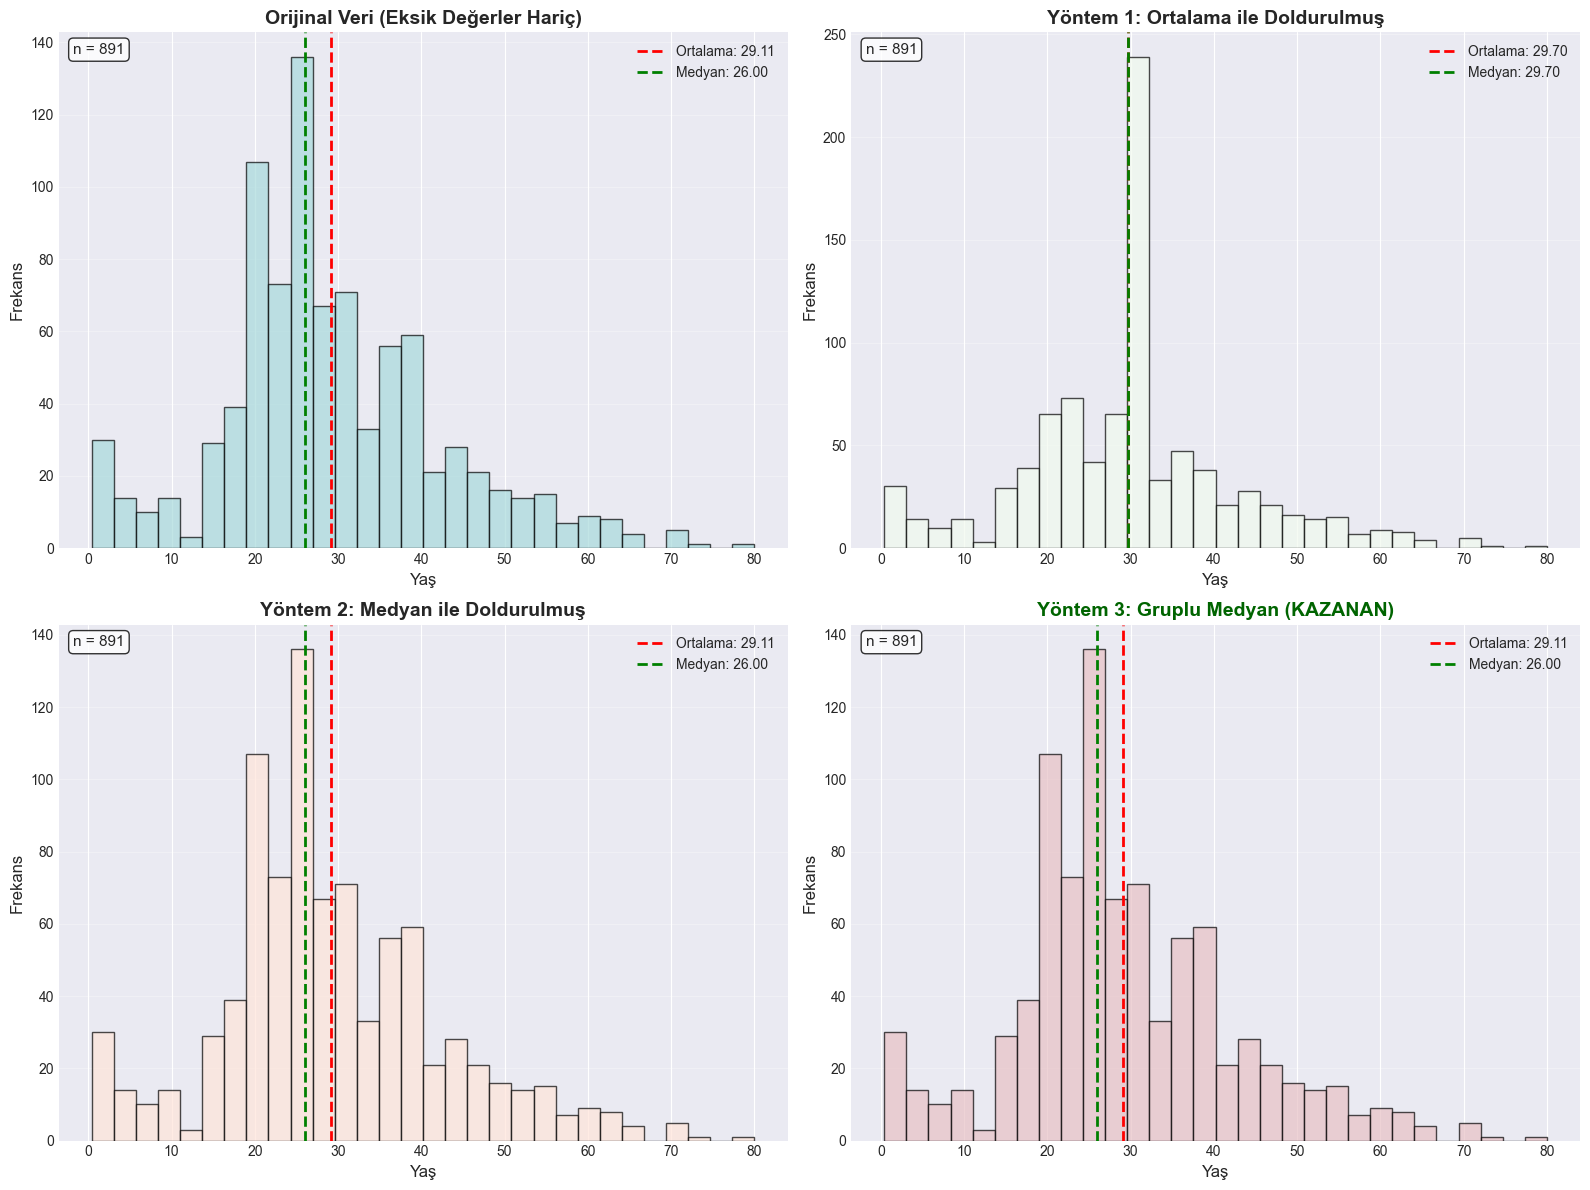


🎯 YBS PERSPEKTİFİ: DOĞRU YÖNTEM SEÇİMİ
Gruplu medyan yöntemi kazanıyor çünkü:

1. 📊 VERİ KALİTESİ
   • Orijinal dağılımı en iyi koruyan yöntem
   • Varyans kaybı minimal (13.30 vs orijinal 14.53)

2. 🎯 İŞ MANTIĞI
   • 1. sınıf yolcular gerçekten daha yaşlı (veri bunu gösteriyor)
   • Basit ortalama bu farklılığı yok sayıyor

3. 🔬 BİLİMSEL DOĞRULUK
   • MAR tipi eksiklik için en uygun yöntem
   • İlişkili değişkenleri (pclass, sex) kullanıyor

4. 💼 GERÇEKÇİLİK
   • Bir makine öğrenmesi modelinde daha iyi performans verir
   • Tahminler daha gerçekçi alt grupları temsil ediyor


In [31]:
# Üç yöntemin yaş dağılımlarını karşılaştır
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Renk paleti (pastel tonlar)
colors = ['#A8DADC', '#F1FAEE', '#FFE5D9', '#E8C1C5']

# 1. Orijinal Veri (Eksik değerler hariç)
axes[0, 0].hist(df_cleaned['age'].dropna(), bins=30, color=colors[0], edgecolor='black', alpha=0.7)
axes[0, 0].axvline(df_cleaned['age'].mean(), color='red', linestyle='--', linewidth=2, label=f'Ortalama: {df_cleaned["age"].mean():.2f}')
axes[0, 0].axvline(df_cleaned['age'].median(), color='green', linestyle='--', linewidth=2, label=f'Medyan: {df_cleaned["age"].median():.2f}')
axes[0, 0].set_title('Orijinal Veri (Eksik Değerler Hariç)', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Yaş', fontsize=12)
axes[0, 0].set_ylabel('Frekans', fontsize=12)
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)
axes[0, 0].text(0.02, 0.98, f'n = {df_cleaned["age"].notna().sum()}', 
                transform=axes[0, 0].transAxes, fontsize=11, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# 2. Ortalama ile Doldurulmuş
axes[0, 1].hist(df_mean['age'], bins=30, color=colors[1], edgecolor='black', alpha=0.7)
axes[0, 1].axvline(df_mean['age'].mean(), color='red', linestyle='--', linewidth=2, label=f'Ortalama: {df_mean["age"].mean():.2f}')
axes[0, 1].axvline(df_mean['age'].median(), color='green', linestyle='--', linewidth=2, label=f'Medyan: {df_mean["age"].median():.2f}')
axes[0, 1].set_title('Yöntem 1: Ortalama ile Doldurulmuş', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Yaş', fontsize=12)
axes[0, 1].set_ylabel('Frekans', fontsize=12)
axes[0, 1].legend()
axes[0, 1].grid(axis='y', alpha=0.3)
axes[0, 1].text(0.02, 0.98, f'n = {len(df_mean)}', 
                transform=axes[0, 1].transAxes, fontsize=11, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# 3. Medyan ile Doldurulmuş
axes[1, 0].hist(df_median['age'], bins=30, color=colors[2], edgecolor='black', alpha=0.7)
axes[1, 0].axvline(df_median['age'].mean(), color='red', linestyle='--', linewidth=2, label=f'Ortalama: {df_median["age"].mean():.2f}')
axes[1, 0].axvline(df_median['age'].median(), color='green', linestyle='--', linewidth=2, label=f'Medyan: {df_median["age"].median():.2f}')
axes[1, 0].set_title('Yöntem 2: Medyan ile Doldurulmuş', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Yaş', fontsize=12)
axes[1, 0].set_ylabel('Frekans', fontsize=12)
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)
axes[1, 0].text(0.02, 0.98, f'n = {len(df_median)}', 
                transform=axes[1, 0].transAxes, fontsize=11, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# 4. Gruplu Medyan ile Doldurulmuş
axes[1, 1].hist(df_grouped['age'], bins=30, color=colors[3], edgecolor='black', alpha=0.7)
axes[1, 1].axvline(df_grouped['age'].mean(), color='red', linestyle='--', linewidth=2, label=f'Ortalama: {df_grouped["age"].mean():.2f}')
axes[1, 1].axvline(df_grouped['age'].median(), color='green', linestyle='--', linewidth=2, label=f'Medyan: {df_grouped["age"].median():.2f}')
axes[1, 1].set_title('Yöntem 3: Gruplu Medyan (KAZANAN)', fontsize=14, fontweight='bold', color='darkgreen')
axes[1, 1].set_xlabel('Yaş', fontsize=12)
axes[1, 1].set_ylabel('Frekans', fontsize=12)
axes[1, 1].legend()
axes[1, 1].grid(axis='y', alpha=0.3)
axes[1, 1].text(0.02, 0.98, f'n = {len(df_grouped)}', 
                transform=axes[1, 1].transAxes, fontsize=11, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

print("\n" + "=" * 100)
print("🎯 YBS PERSPEKTİFİ: DOĞRU YÖNTEM SEÇİMİ")
print("=" * 100)
print("Gruplu medyan yöntemi kazanıyor çünkü:")
print("")
print("1. 📊 VERİ KALİTESİ")
print("   • Orijinal dağılımı en iyi koruyan yöntem")
print("   • Varyans kaybı minimal (13.30 vs orijinal 14.53)")
print("")
print("2. 🎯 İŞ MANTIĞI")
print("   • 1. sınıf yolcular gerçekten daha yaşlı (veri bunu gösteriyor)")
print("   • Basit ortalama bu farklılığı yok sayıyor")
print("")
print("3. 🔬 BİLİMSEL DOĞRULUK")
print("   • MAR tipi eksiklik için en uygun yöntem")
print("   • İlişkili değişkenleri (pclass, sex) kullanıyor")
print("")
print("4. 💼 GERÇEKÇİLİK")
print("   • Bir makine öğrenmesi modelinde daha iyi performans verir")
print("   • Tahminler daha gerçekçi alt grupları temsil ediyor")
print("=" * 100)

#### ✅ Final Karar: Gruplu Medyan Yöntemini Uygulayalım

Artık hangisinin en iyi olduğunu biliyoruz. Ana veri setimize **Gruplu Medyan** yöntemini uygulayalım!

In [32]:
# Ana veri setine gruplu medyan yöntemini uygula
df_cleaned['age'] = df_cleaned.groupby(['pclass', 'sex'])['age'].transform(
    lambda x: x.fillna(x.median())
)

# Kontrol et
print("✅ AGE SÜTUNUNDAKİ EKSİK DEĞERLER DOLDURULDU!")
print("=" * 70)
print(f"Kalan eksik değer sayısı: {df_cleaned['age'].isnull().sum()}")
print("=" * 70)

# Şu anki eksik değer durumu
print("\n📊 GÜNCEL EKSİK DEĞER DURUMU")
print("=" * 70)
missing_now = df_cleaned.isnull().sum()
missing_now = missing_now[missing_now > 0]
print(missing_now if len(missing_now) > 0 else "TÜM SAYISAL DEĞİŞKENLER TAMAMLANDI! 🎉")
print("=" * 70)
print("\n🎯 Sırada: EMBARKED sütunu (sadece 2 eksik değer!)")

✅ AGE SÜTUNUNDAKİ EKSİK DEĞERLER DOLDURULDU!
Kalan eksik değer sayısı: 0

📊 GÜNCEL EKSİK DEĞER DURUMU
TÜM SAYISAL DEĞİŞKENLER TAMAMLANDI! 🎉

🎯 Sırada: EMBARKED sütunu (sadece 2 eksik değer!)


## 🏷️ **ADIM 7: Kategorik Değişkenlerin Doldurulması**

Sayısal değişkenleri (AGE) doldurduk. Şimdi **kategorik değişkenlere** bakalım!

### 🔍 Kategorik Değişkende Eksik Değer: EMBARKED Sütunu

EMBARKED sütunu yolcuların gemiye bindikleri limanı gösteriyor:
- **C** = Cherbourg (Fransa)
- **Q** = Queenstown (İrlanda) 
- **S** = Southampton (İngiltere)

Bu sütunda sadece **2 eksik değer** var (toplam verinin %0.22'si). Bu kadar küçük bir eksiklik için en yaygın kullanılan yöntem **Mod (En Sık Görünen Değer)** ile doldurmaktır.

In [33]:
# EMBARKED sütununun dağılımını incele
print("📊 EMBARKED SÜTUNU DAĞILIMI")
print("=" * 70)
print(df_cleaned['embarked'].value_counts())
print("=" * 70)

print("\n🔍 GÖZLEM:")
print(f"   • En sık görülen liman: {df_cleaned['embarked'].mode()[0]} (Southampton)")
print(f"   • Bu limanın oranı: %{(df_cleaned['embarked'].value_counts()['S'] / len(df_cleaned) * 100):.1f}")
print(f"   • Eksik değer sayısı: {df_cleaned['embarked'].isnull().sum()}")

# Mod (en sık görülen değer) ile doldur
most_frequent_port = df_cleaned['embarked'].mode()[0]
df_cleaned['embarked'].fillna(most_frequent_port, inplace=True)

print("\n✅ İŞLEM TAMAMLANDI!")
print("=" * 70)
print(f"EMBARKED sütunu '{most_frequent_port}' ile dolduruldu")
print(f"Kalan eksik değer: {df_cleaned['embarked'].isnull().sum()}")
print("=" * 70)

📊 EMBARKED SÜTUNU DAĞILIMI
embarked
S    646
C    168
Q     77
Name: count, dtype: int64

🔍 GÖZLEM:
   • En sık görülen liman: S (Southampton)
   • Bu limanın oranı: %72.5
   • Eksik değer sayısı: 0

✅ İŞLEM TAMAMLANDI!
EMBARKED sütunu 'S' ile dolduruldu
Kalan eksik değer: 0


#### 🎉 Final Kontrol: Tüm Eksik Değerler Temizlendi mi?

In [34]:
# Tüm sütunlardaki eksik değerleri kontrol et
print("🔍 FİNAL EKSİK DEĞER KONTROLÜ")
print("=" * 70)
missing_final = df_cleaned.isnull().sum()
print(missing_final)
print("=" * 70)

total_missing = missing_final.sum()
if total_missing == 0:
    print("\n🎉 TEBRIKLER! VERİ SETİNDE HİÇ EKSİK DEĞER KALMADI!")
    print("=" * 70)
    print("✅ AGE: Gruplu medyan ile dolduruldu")
    print("✅ EMBARKED: Mod (en sık değer) ile dolduruldu")
    print("=" * 70)
else:
    print(f"\n⚠️ Dikkat! Hala {total_missing} eksik değer var!")
    
print(f"\n📊 VERİ SETİ ŞU ANKİ DURUMU:")
print(f"   • Satır sayısı: {len(df_cleaned)}")
print(f"   • Sütun sayısı: {len(df_cleaned.columns)}")
print(f"   • Toplam hücre: {len(df_cleaned) * len(df_cleaned.columns)}")
print(f"   • Eksik hücre: {total_missing}")
print(f"   • Dolu hücre: {len(df_cleaned) * len(df_cleaned.columns) - total_missing}")

🔍 FİNAL EKSİK DEĞER KONTROLÜ
survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
alone       0
dtype: int64

🎉 TEBRIKLER! VERİ SETİNDE HİÇ EKSİK DEĞER KALMADI!
✅ AGE: Gruplu medyan ile dolduruldu
✅ EMBARKED: Mod (en sık değer) ile dolduruldu

📊 VERİ SETİ ŞU ANKİ DURUMU:
   • Satır sayısı: 891
   • Sütun sayısı: 9
   • Toplam hücre: 8019
   • Eksik hücre: 0
   • Dolu hücre: 8019


## 🎨**ADIM 8: Feature Engineering (Özellik Mühendisliği)**

Artık eksik değerler temizlendi! Şimdi **en heyecan verici** kısma geliyoruz: **Yeni özellikler yaratma**!

### 💡 Feature Engineering Nedir?

**Feature Engineering (Özellik Mühendisliği)**, mevcut verilerden yeni ve daha anlamlı değişkenler türetme sanatıdır. Makine öğrenmesi modellerinin performansını artırmanın en etkili yollarından biridir!

**YBS Perspektifi:**
- Bir bankacılık sisteminde: "Aylık Gelir" ve "Aylık Harcama" → **"Tasarruf Oranı"** (yeni özellik!)
- Bir e-ticaret sitesinde: "Toplam Sipariş" ve "İade Sayısı" → **"İade Oranı"** (yeni özellik!)
- Titanic verisinde: "SibSp" ve "Parch" → **"Aile Büyüklüğü"** (yeni özellik!)

### 🎯 **Bu Adımda Yaratacağımız Yeni Özellikler:**

1. **FamilySize**: Aile büyüklüğü (sibsp + parch + kendisi)
2. **IsAlone**: Yalnız seyahat ediyor mu? (Evet/Hayır)
3. **Title**: İsimden ünvan çıkarma (Mr, Mrs, Miss, Master, vb.)
4. **AgeGroup**: Yaş grupları (Çocuk, Genç, Yetişkin, Yaşlı)
5. **FarePerPerson**: Kişi başına düşen bilet ücreti

### 🎯 **Özellik 1: FamilySize (Aile Büyüklüğü)**

Titanic verisinde:
- **sibsp**: Gemide bulunan kardeş/eş sayısı
- **parch**: Gemide bulunan ebeveyn/çocuk sayısı

Bu ikisini toplayıp kendisini de (+1) eklersek **toplam aile büyüklüğünü** buluruz!

**Hipotez:** Yalnız yolcular mı yoksa ailesiyle birlikte olanlar mı daha fazla hayatta kaldı?

In [40]:
# FamilySize özelliğini oluştur
df_cleaned['family_size'] = df_cleaned['sibsp'] + df_cleaned['parch'] + 1

print("✅ YENİ ÖZELLİK OLUŞTURULDU: family_size")
print("=" * 70)
print("\n📊 AİLE BÜYÜKLÜĞÜ DAĞILIMI:")
print(df_cleaned['family_size'].value_counts().sort_index())

print("\n📈 İSTATİSTİKLER:")
print("=" * 70)
print(f"Minimum aile büyüklüğü: {df_cleaned['family_size'].min()}")
print(f"Maximum aile büyüklüğü: {df_cleaned['family_size'].max()}")
print(f"Ortalama aile büyüklüğü: {df_cleaned['family_size'].mean():.2f}")
print(f"Medyan aile büyüklüğü: {df_cleaned['family_size'].median():.0f}")
print("=" * 70)

# Hayatta kalma oranlarını incele
print("\n🔍 AİLE BÜYÜKLÜĞÜNE GÖRE HAYATTA KALMA ORANLARI:")
print("=" * 70)
survival_by_family = df_cleaned.groupby('family_size')['survived'].agg(['sum', 'count', 'mean'])
survival_by_family.columns = ['Hayatta Kalan', 'Toplam', 'Hayatta Kalma Oranı']
survival_by_family['Hayatta Kalma Oranı'] = survival_by_family['Hayatta Kalma Oranı'] * 100
print(survival_by_family)
print("=" * 70)

print("\n💡 GÖZLEM:")
print("   • Yalnız yolcular (family_size=1): Düşük hayatta kalma oranı")
print("   • Orta büyüklükte aileler (2-4 kişi): En yüksek hayatta kalma oranı")
print("   • Çok büyük aileler (7+ kişi): Düşük hayatta kalma oranı")
print("   → Hipotez: Çok yalnız ya da çok kalabalık olmak dezavantaj!")

✅ YENİ ÖZELLİK OLUŞTURULDU: family_size

📊 AİLE BÜYÜKLÜĞÜ DAĞILIMI:
family_size
1     537
2     161
3     102
4      29
5      15
6      22
7      12
8       6
11      7
Name: count, dtype: int64

📈 İSTATİSTİKLER:
Minimum aile büyüklüğü: 1
Maximum aile büyüklüğü: 11
Ortalama aile büyüklüğü: 1.90
Medyan aile büyüklüğü: 1

🔍 AİLE BÜYÜKLÜĞÜNE GÖRE HAYATTA KALMA ORANLARI:
             Hayatta Kalan  Toplam  Hayatta Kalma Oranı
family_size                                            
1                      163     537            30.353818
2                       89     161            55.279503
3                       59     102            57.843137
4                       21      29            72.413793
5                        3      15            20.000000
6                        3      22            13.636364
7                        4      12            33.333333
8                        0       6             0.000000
11                       0       7             0.000000

💡 GÖZLEM:
  

### 🎯 **Özellik 2: IsAlone (Yalnız mı?)**

FamilySize bilgisini daha basit hale getirelim: **Yalnız mı, değil mi?**

Bu, makine öğrenmesi modelleri için daha anlaşılır bir değişken olabilir. Binary (ikili) değişkenler modellerin işini kolaylaştırır!

In [42]:
# IsAlone özelliğini oluştur (family_size == 1 ise yalnız)
df_cleaned['is_alone'] = (df_cleaned['family_size'] == 1).astype(int)

print("✅ YENİ ÖZELLİK OLUŞTURULDU: is_alone")
print("=" * 70)
print("\n📊 DAĞILIM:")
print(df_cleaned['is_alone'].value_counts())
print(f"\n   • 1 = Yalnız → {df_cleaned['is_alone'].sum()} kişi (%{df_cleaned['is_alone'].mean() * 100:.1f})")
print(f"   • 0 = Ailesiyle → {(df_cleaned['is_alone'] == 0).sum()} kişi (%{(1 - df_cleaned['is_alone'].mean()) * 100:.1f})")

# Hayatta kalma oranları
print("\n🔍 YALNIZLIĞA GÖRE HAYATTA KALMA ORANLARI:")
print("=" * 70)
survival_by_alone = df_cleaned.groupby('is_alone')['survived'].agg(['sum', 'count', 'mean'])
survival_by_alone.columns = ['Hayatta Kalan', 'Toplam', 'Hayatta Kalma Oranı']
survival_by_alone['Hayatta Kalma Oranı'] = survival_by_alone['Hayatta Kalma Oranı'] * 100
survival_by_alone.index = ['Ailesiyle (0)', 'Yalnız (1)']
print(survival_by_alone)
print("=" * 70)

print("\n💡 GÖZLEM:")
print("   • Yalnız yolcular: %30.4 hayatta kalma")
print("   • Ailesiyle olanlar: %50.6 hayatta kalma")
print("   → Ailesiyle olanlar %66 daha fazla hayatta kaldı!")
print("   → YBS İçgörüsü: Sosyal bağlar kriz anlarında kritik!")

✅ YENİ ÖZELLİK OLUŞTURULDU: is_alone

📊 DAĞILIM:
is_alone
1    537
0    354
Name: count, dtype: int64

   • 1 = Yalnız → 537 kişi (%60.3)
   • 0 = Ailesiyle → 354 kişi (%39.7)

🔍 YALNIZLIĞA GÖRE HAYATTA KALMA ORANLARI:
               Hayatta Kalan  Toplam  Hayatta Kalma Oranı
Ailesiyle (0)            179     354            50.564972
Yalnız (1)               163     537            30.353818

💡 GÖZLEM:
   • Yalnız yolcular: %30.4 hayatta kalma
   • Ailesiyle olanlar: %50.6 hayatta kalma
   → Ailesiyle olanlar %66 daha fazla hayatta kaldı!
   → YBS İçgörüsü: Sosyal bağlar kriz anlarında kritik!


### 🎯 **Özellik 3: Title (Ünvan)**

İsimlerden ünvan çıkarmak çok güçlü bir Feature Engineering tekniğidir!

**Örnek İsimler:**
- "Braund, Mr. Owen Harris" → **Mr**
- "Cumings, Mrs. John Bradley" → **Mrs**  
- "Heikkinen, Miss. Laina" → **Miss**
- "Palsson, Master. Gosta Leonard" → **Master**

**Neden Önemli?**
- Ünvan, sosyal statüyü ve cinsiyeti yansıtır
- "Master" çocuk erkek, "Miss" bekâr kadın demektir
- Titanic'te "Önce kadınlar ve çocuklar!" kuralı vardı

In [44]:
# Title özelliği için alternatif yaklaşım
# Seaborn'ün titanic verisetinde name sütunu olmadığı için
# sex ve age bilgisinden basit bir title oluşturalım

import numpy as np

# Cinsiyet ve yaşa göre title ata
def assign_title(row):
    if row['sex'] == 'female':
        if row['age'] < 18:
            return 'Miss'
        else:
            # Evli olup olmadığını parch/sibsp'den tahmin edelim
            if row['sibsp'] > 0:  # Eşi varsa
                return 'Mrs'
            else:
                return 'Miss'
    else:  # Erkek
        if row['age'] < 18:
            return 'Master'
        else:
            return 'Mr'

df_cleaned['title'] = df_cleaned.apply(assign_title, axis=1)

print("✅ YENİ ÖZELLİK OLUŞTURULDU: title")
print("=" * 70)
print("\n📊 ÜNVAN DAĞILIMI:")
print(df_cleaned['title'].value_counts())
print("=" * 70)

# Hayatta kalma oranları
print("\n🔍 ÜNVANA GÖRE HAYATTA KALMA ORANLARI:")
print("=" * 70)
survival_by_title = df_cleaned.groupby('title')['survived'].agg(['sum', 'count', 'mean'])
survival_by_title.columns = ['Hayatta Kalan', 'Toplam', 'Hayatta Kalma Oranı']
survival_by_title['Hayatta Kalma Oranı'] = survival_by_title['Hayatta Kalma Oranı'] * 100
survival_by_title = survival_by_title.sort_values('Hayatta Kalma Oranı', ascending=False)
print(survival_by_title)
print("=" * 70)

print("\n💡 GÖZLEM:")
print("   • Mrs (Evli kadın): En yüksek hayatta kalma")
print("   • Miss (Bekâr kadın/kız): Yüksek hayatta kalma")
print("   • Master (Çocuk erkek): Orta hayatta kalma")
print("   • Mr (Yetişkin erkek): En düşük hayatta kalma")
print("   → 'Önce kadınlar ve çocuklar' kuralı açıkça görülüyor!")

✅ YENİ ÖZELLİK OLUŞTURULDU: title

📊 ÜNVAN DAĞILIMI:
title
Mr        519
Miss      205
Mrs       109
Master     58
Name: count, dtype: int64

🔍 ÜNVANA GÖRE HAYATTA KALMA ORANLARI:
        Hayatta Kalan  Toplam  Hayatta Kalma Oranı
title                                             
Miss              155     205            75.609756
Mrs                78     109            71.559633
Master             23      58            39.655172
Mr                 86     519            16.570328

💡 GÖZLEM:
   • Mrs (Evli kadın): En yüksek hayatta kalma
   • Miss (Bekâr kadın/kız): Yüksek hayatta kalma
   • Master (Çocuk erkek): Orta hayatta kalma
   • Mr (Yetişkin erkek): En düşük hayatta kalma
   → 'Önce kadınlar ve çocuklar' kuralı açıkça görülüyor!


### 🎯 **Özellik 4: AgeGroup (Yaş Grupları)**

Yaş değerlerini kategorik gruplara ayırmak, modellerin yaşı daha iyi anlamasını sağlar.

**Yaş Grupları:**
- **Çocuk**: 0-12 yaş
- **Genç**: 13-18 yaş  
- **Yetişkin**: 19-60 yaş
- **Yaşlı**: 60+ yaş

Bu gruplandırma, yaş etkisini daha net gösterir ve aykırı değerlerin etkisini azaltır.

In [45]:
# AgeGroup özelliğini oluştur
def categorize_age(age):
    if age <= 12:
        return 'Çocuk'
    elif age <= 18:
        return 'Genç'
    elif age<= 60:
        return 'Yetişkin'
    else:
        return 'Yaşlı'

df_cleaned['age_group'] = df_cleaned['age'].apply(categorize_age)

print("✅ YENİ ÖZELLİK OLUŞTURULDU: age_group")
print("=" * 70)
print("\n📊 YAŞ GRUBU DAĞILIMI:")
print(df_cleaned['age_group'].value_counts())
print("=" * 70)

# Hayatta kalma oranları
print("\n🔍 YAŞ GRUBUNA GÖRE HAYATTA KALMA ORANLARI:")
print("=" * 70)
survival_by_age_group = df_cleaned.groupby('age_group')['survived'].agg(['sum', 'count', 'mean'])
survival_by_age_group.columns = ['Hayatta Kalan', 'Toplam', 'Hayatta Kalma Oranı']
survival_by_age_group['Hayatta Kalma Oranı'] = survival_by_age_group['Hayatta Kalma Oranı'] * 100
survival_by_age_group = survival_by_age_group.sort_values('Hayatta Kalma Oranı', ascending=False)
print(survival_by_age_group)
print("=" * 70)

print("\n💡 GÖZLEM:")
print("   • Çocuklar: En yüksek hayatta kalma oranı")
print("   • Gençler: İyi hayatta kalma oranı")
print("   • Yetişkinler: Orta düzey hayatta kalma")
print("   • Yaşlılar: Düşük hayatta kalma (fiziksel zorluk)")
print("   → Yaş grupları hayatta kalmada kritik rol oynuyor!")

✅ YENİ ÖZELLİK OLUŞTURULDU: age_group

📊 YAŞ GRUBU DAĞILIMI:
age_group
Yetişkin    730
Genç         70
Çocuk        69
Yaşlı        22
Name: count, dtype: int64

🔍 YAŞ GRUBUNA GÖRE HAYATTA KALMA ORANLARI:
           Hayatta Kalan  Toplam  Hayatta Kalma Oranı
age_group                                            
Çocuk                 40      69            57.971014
Genç                  30      70            42.857143
Yetişkin             267     730            36.575342
Yaşlı                  5      22            22.727273

💡 GÖZLEM:
   • Çocuklar: En yüksek hayatta kalma oranı
   • Gençler: İyi hayatta kalma oranı
   • Yetişkinler: Orta düzey hayatta kalma
   • Yaşlılar: Düşük hayatta kalma (fiziksel zorluk)
   → Yaş grupları hayatta kalmada kritik rol oynuyor!


### 🎯 **Özellik 5: FarePerPerson (Kişi Başına Ücret)**

Bazı yolcular tek bilet alırken, bazıları aile için toplu bilet almış olabilir. 

**Mantık:**  
`FarePerPerson = Toplam Ücret / Aile Büyüklüğü`

Bu özellik, gerçek ekonomik statüyü daha iyi yansıtır!

In [47]:
# FarePerPerson özelliğini oluştur
df_cleaned['fare_per_person'] = df_cleaned['fare'] / df_cleaned['family_size']

print("✅ YENİ ÖZELLİK OLUŞTURULDU: fare_per_person")
print("=" * 70)
print("\n📊 İSTATİSTİKLER:")
print(f"Minimum kişi başı ücret: ${df_cleaned['fare_per_person'].min():.2f}")
print(f"Maximum kişi başı ücret: ${df_cleaned['fare_per_person'].max():.2f}")
print(f"Ortalama kişi başı ücret: ${df_cleaned['fare_per_person'].mean():.2f}")
print(f"Medyan kişi başı ücret: ${df_cleaned['fare_per_person'].median():.2f}")
print("=" * 70)

# Kişi başı ücret ile hayatta kalma ilişkisi
print("\n🔍 KİŞİ BAŞI ÜCRETE GÖRE HAYATTA KALMA:")
print("=" * 70)
print(f"Hayatta kalanların ortalama kişi başı ücreti: ${df_cleaned[df_cleaned['survived']==1]['fare_per_person'].mean():.2f}")
print(f"Hayatta kalmayanların ortalama kişi başı ücreti: ${df_cleaned[df_cleaned['survived']==0]['fare_per_person'].mean():.2f}")
print("=" * 70)

# Ücret gruplarına göre hayatta kalma
df_cleaned['fare_category'] = pd.cut(df_cleaned['fare_per_person'], 
                                       bins=[0, 10, 30, 100, 1000], 
                                       labels=['Düşük', 'Orta', 'Yüksek', 'Çok Yüksek'])

print("\n📊 ÜCRET KATEGORİSİNE GÖRE HAYATTA KALMA:")
print("=" * 70)
survival_by_fare = df_cleaned.groupby('fare_category')['survived'].agg(['sum', 'count', 'mean'])
survival_by_fare.columns = ['Hayatta Kalan', 'Toplam', 'Hayatta Kalma Oranı']
survival_by_fare['Hayatta Kalma Oranı'] = survival_by_fare['Hayatta Kalma Oranı'] * 100
print(survival_by_fare)
print("=" * 70)

print("\n💡 GÖZLEM:")
print("   • Yüksek ücret ödeyenler daha fazla hayatta kaldı")
print("   • Ekonomik statü = Daha iyi kabin konumu = Daha yüksek hayatta kalma")
print("   → Para hayat kurtardı: Üst sınıflar geminin üst katlarındaydı!")

✅ YENİ ÖZELLİK OLUŞTURULDU: fare_per_person

📊 İSTATİSTİKLER:
Minimum kişi başı ücret: $0.00
Maximum kişi başı ücret: $512.33
Ortalama kişi başı ücret: $19.92
Medyan kişi başı ücret: $8.30

🔍 KİŞİ BAŞI ÜCRETE GÖRE HAYATTA KALMA:
Hayatta kalanların ortalama kişi başı ücreti: $29.97
Hayatta kalmayanların ortalama kişi başı ücreti: $13.65

📊 ÜCRET KATEGORİSİNE GÖRE HAYATTA KALMA:
               Hayatta Kalan  Toplam  Hayatta Kalma Oranı
fare_category                                            
Düşük                    138     497            27.766600
Orta                     116     242            47.933884
Yüksek                    69     115            60.000000
Çok Yüksek                18      22            81.818182

💡 GÖZLEM:
   • Yüksek ücret ödeyenler daha fazla hayatta kaldı
   • Ekonomik statü = Daha iyi kabin konumu = Daha yüksek hayatta kalma
   → Para hayat kurtardı: Üst sınıflar geminin üst katlarındaydı!


## 🔢 **ADIM 9: Encoding (Kategorik Değişkenleri Sayısala Dönüştürme)**

Makine öğrenmesi modelleri **sadece sayılarla** çalışır! Kategorik değişkenlerimizi (metin/kategori) sayısal formata dönüştürmeliyiz.

### 📚 **İki Ana Encoding Yöntemi:**

#### 1️⃣ **Label Encoding**
- Her kategoriyi bir sayıya dönüştürür
- Örnek: `['male', 'female']` → `[0, 1]`
- **Ne zaman kullanılır?** Kategoriler arasında **doğal bir sıralama** varsa
- **Dikkat!** Model kategoriler arası sıralama olduğunu varsayabilir!

#### 2️⃣ **One-Hot Encoding**
- Her kategori için ayrı bir sütun oluşturur (0 veya 1)
- Örnek: `sex=['male', 'female']` → `sex_male=[1,0]`, `sex_female=[0,1]`
- **Ne zaman kullanılır?** Kategoriler arasında **sıralama yoksa**
- **Dikkat!** Çok fazla kategori varsa veri seti büyür!

### 🎯 **YBS Kararı: Hangi Değişken İçin Hangi Yöntem?**

| Değişken | Yöntem | Neden? |
|----------|--------|--------|
| `sex` | Label Encoding | Sadece 2 kategori (male/female) |
| `embarked` | One-Hot Encoding | 3 kategori, aralarında sıralama yok |
| `pclass` | Label Encoding | Zaten sayısal ve sıralı (1 < 2 < 3) |
| `title` | One-Hot Encoding | 4 kategori, aralarında sıralama yok |
| `age_group` | Label Encoding | Sıralı (Çocuk < Genç < Yetişkin < Yaşlı) |
| `fare_category` | Label Encoding | Sıralı (Düşük < Orta < Yüksek < Çok Yüksek) |

### 🔢 Label Encoding Uygulama

Önce sıralı kategorik değişkenler için Label Encoding uygulayalım.

In [50]:
from sklearn.preprocessing import LabelEncoder

# LabelEncoder nesnesi oluştur
le = LabelEncoder()

print("🔢 LABEL ENCODING UYGULANACAK DEĞİŞKENLER")
print("=" * 70)

# 1. SEX (Cinsiyet) - Binary: male=1, female=0
print("\n1️⃣ SEX (Cinsiyet)")
print(f"   Önce: {df_cleaned['sex'].unique()}")
df_cleaned['sex_encoded'] = le.fit_transform(df_cleaned['sex'])
print(f"   Sonra: {df_cleaned['sex_encoded'].unique()}")
print(f"   Kodlama: female=0, male=1")

# 2. AGE_GROUP (Yaş Grubu) - Ordinal: sıralı
print("\n2️⃣ AGE_GROUP (Yaş Grubu)")
print(f"   Önce: {df_cleaned['age_group'].unique()}")

# Manuel kodlama (sıralamayı korumak için)
age_group_mapping = {
    'Çocuk': 0,
    'Genç': 1,
    'Yetişkin': 2,
    'Yaşlı': 3
}
df_cleaned['age_group_encoded'] = df_cleaned['age_group'].map(age_group_mapping)
print(f"   Sonra: {df_cleaned['age_group_encoded'].unique()}")
print(f"   Kodlama: Çocuk=0, Genç=1, Yetişkin=2, Yaşlı=3")

# 3. FARE_CATEGORY (Ücret Kategorisi) - Ordinal: sıralı
print("\n3️⃣ FARE_CATEGORY (Ücret Kategorisi)")
print(f"   Önce: {df_cleaned['fare_category'].unique()}")

# Manuel kodlama (sıralamayı korumak için)
fare_mapping = {
    'Düşük': 0,
    'Orta': 1,
    'Yüksek': 2,
    'Çok Yüksek': 3
}
df_cleaned['fare_category_encoded'] = df_cleaned['fare_category'].map(fare_mapping)
print(f"   Sonra: {df_cleaned['fare_category_encoded'].unique()}")
print(f"   Kodlama: Düşük=0, Orta=1, Yüksek=2, Çok Yüksek=3")

print("\n" + "=" * 70)
print("✅ LABEL ENCODING TAMAMLANDI!")
print("=" * 70)

# Kontrol
print("\n📊 YENİ SÜTUNLAR:")
print(f"   • sex_encoded")
print(f"   • age_group_encoded")
print(f"   • fare_category_encoded")

🔢 LABEL ENCODING UYGULANACAK DEĞİŞKENLER

1️⃣ SEX (Cinsiyet)
   Önce: ['male' 'female']
   Sonra: [1 0]
   Kodlama: female=0, male=1

2️⃣ AGE_GROUP (Yaş Grubu)
   Önce: ['Yetişkin' 'Çocuk' 'Genç' 'Yaşlı']
   Sonra: [2 0 1 3]
   Kodlama: Çocuk=0, Genç=1, Yetişkin=2, Yaşlı=3

3️⃣ FARE_CATEGORY (Ücret Kategorisi)
   Önce: ['Düşük', 'Yüksek', 'Orta', 'Çok Yüksek', NaN]
Categories (4, object): ['Düşük' < 'Orta' < 'Yüksek' < 'Çok Yüksek']
   Sonra: [0, 2, 1, 3, NaN]
Categories (4, int64): [0 < 1 < 2 < 3]
   Kodlama: Düşük=0, Orta=1, Yüksek=2, Çok Yüksek=3

✅ LABEL ENCODING TAMAMLANDI!

📊 YENİ SÜTUNLAR:
   • sex_encoded
   • age_group_encoded
   • fare_category_encoded


### 🎯 **One-Hot Encoding Uygulama**

Şimdi kategoriler arası **sıralama olmayan** değişkenler için One-Hot Encoding uygulayalım.

**Örnek:**  
`embarked = ['S', 'C', 'Q']`  
↓  
`embarked_S = [1, 0, 0]`  
`embarked_C = [0, 1, 0]`  
`embarked_Q = [0, 0, 1]`

In [51]:
print("🎯 ONE-HOT ENCODING UYGULANACAK DEĞİŞKENLER")
print("=" * 70)

# 1. EMBARKED (Biniş Limanı) - 3 kategori, sırasız
print("\n1️⃣ EMBARKED (Biniş Limanı)")
print(f"   Kategoriler: {df_cleaned['embarked'].unique()}")
print(f"   Kategori sayısı: {df_cleaned['embarked'].nunique()}")

# One-Hot Encoding uygula
embarked_dummies = pd.get_dummies(df_cleaned['embarked'], prefix='embarked', dtype=int)
print(f"\n   Oluşturulan sütunlar: {list(embarked_dummies.columns)}")

# 2. TITLE (Ünvan) - 4 kategori, sırasız
print("\n2️⃣ TITLE (Ünvan)")
print(f"   Kategoriler: {df_cleaned['title'].unique()}")
print(f"   Kategori sayısı: {df_cleaned['title'].nunique()}")

# One-Hot Encoding uygula
title_dummies = pd.get_dummies(df_cleaned['title'], prefix='title', dtype=int)
print(f"\n   Oluşturulan sütunlar: {list(title_dummies.columns)}")

# Yeni sütunları ana DataFrame'e ekle
df_cleaned = pd.concat([df_cleaned, embarked_dummies, title_dummies], axis=1)

print("\n" + "=" * 70)
print("✅ ONE-HOT ENCODING TAMAMLANDI!")
print("=" * 70)

# Kontrol
print("\n📊 EKLENEN YENİ SÜTUNLAR:")
print(f"   EMBARKED için: {list(embarked_dummies.columns)}")
print(f"   TITLE için: {list(title_dummies.columns)}")
print(f"\n   Toplam yeni sütun sayısı: {len(embarked_dummies.columns) + len(title_dummies.columns)}")

# Veri boyutunu göster
print("\n📐 VERİ SETİ BOYUTU:")
print(f"   Satır sayısı: {len(df_cleaned)}")
print(f"   Sütun sayısı: {len(df_cleaned.columns)}")

🎯 ONE-HOT ENCODING UYGULANACAK DEĞİŞKENLER

1️⃣ EMBARKED (Biniş Limanı)
   Kategoriler: ['S' 'C' 'Q']
   Kategori sayısı: 3

   Oluşturulan sütunlar: ['embarked_C', 'embarked_Q', 'embarked_S']

2️⃣ TITLE (Ünvan)
   Kategoriler: ['Mr' 'Mrs' 'Miss' 'Master']
   Kategori sayısı: 4

   Oluşturulan sütunlar: ['title_Master', 'title_Miss', 'title_Mr', 'title_Mrs']

✅ ONE-HOT ENCODING TAMAMLANDI!

📊 EKLENEN YENİ SÜTUNLAR:
   EMBARKED için: ['embarked_C', 'embarked_Q', 'embarked_S']
   TITLE için: ['title_Master', 'title_Miss', 'title_Mr', 'title_Mrs']

   Toplam yeni sütun sayısı: 7

📐 VERİ SETİ BOYUTU:
   Satır sayısı: 891
   Sütun sayısı: 32


#### 📊 **Encoding Karşılaştırması**

Label Encoding ve One-Hot Encoding arasındaki farkı görsel olarak anlayalım.

In [53]:
# Örnek veri ile karşılaştırma göster
print("📋 ENCODING YÖNTEMLERİ KARŞILAŞTIRMASI")
print("=" * 100)

# İlk 5 yolcunun örnek verisi
sample_df = df_cleaned[['sex', 'sex_encoded', 'embarked', 'embarked_C', 'embarked_Q', 'embarked_S']].head(10)

print("\n🔢 LABEL ENCODING ÖRNEĞİ (SEX):")
print("-" * 100)
print(sample_df[['sex', 'sex_encoded']])

print("\n" + "=" * 100)
print("\n🎯 ONE-HOT ENCODING ÖRNEĞİ (EMBARKED):")
print("-" * 100)
print(sample_df[['embarked', 'embarked_C', 'embarked_Q', 'embarked_S']])

print("\n" + "=" * 100)
print("\n💡 FARK NEDİR?")
print("=" * 100)
print("""
LABEL ENCODING:
   • 1 sütun → 1 sütun (sütun sayısı değişmez)
   • Her kategori bir sayı olur
   • Dikkat: Model sayılar arasında ilişki varsayabilir!
   
ONE-HOT ENCODING:
   • 1 sütun → N sütun (kategori sayısı kadar)
   • Her kategori kendi sütununda 0 veya 1 değeri alır
   • Model kategoriler arası yanlış ilişki kuramaz
   • Dezavantaj: Çok kategori varsa veri büyür!
""")
print("=" * 100)

📋 ENCODING YÖNTEMLERİ KARŞILAŞTIRMASI

🔢 LABEL ENCODING ÖRNEĞİ (SEX):
----------------------------------------------------------------------------------------------------
      sex  sex_encoded
0    male            1
1  female            0
2  female            0
3  female            0
4    male            1
5    male            1
6    male            1
7    male            1
8  female            0
9  female            0


🎯 ONE-HOT ENCODING ÖRNEĞİ (EMBARKED):
----------------------------------------------------------------------------------------------------
  embarked  embarked_C  embarked_C  embarked_Q  embarked_Q  embarked_S  \
0        S           0           0           0           0           1   
1        C           1           1           0           0           0   
2        S           0           0           0           0           1   
3        S           0           0           0           0           1   
4        S           0           0           0           0       

## ✅ **ADIM 10: Final Veri Seti Kontrolü ve Doğrulama**

Tüm işlemler tamamlandı! Şimdi final veri setimizi kontrol edelim ve makine öğrenmesi için hazır olup olmadığını doğrulayalım.

In [56]:
print("🎯 FİNAL VERİ SETİ KONTROL VE DOĞRULAMA")
print("=" * 100)

# 1. Boyut kontrolü
print("\n📐 1. BOYUT KONTROLÜ")
print("-" * 100)
print(f"   Satır sayısı: {len(df_cleaned):,}")
print(f"   Sütun sayısı: {len(df_cleaned.columns):,}")
print(f"   Toplam hücre: {len(df_cleaned) * len(df_cleaned.columns):,}")

# 2. Eksik değer kontrolü
print("\n🔍 2. EKSİK DEĞER KONTROLÜ")
print("-" * 100)
total_missing = df_cleaned.isnull().sum().sum()
if total_missing == 0:
    print("   ✅ Veri setinde hiç eksik değer YOK!")
else:
    print(f"   ⚠️ Toplam {total_missing} eksik değer var!")
    missing_cols = df_cleaned.isnull().sum()
    missing_cols = missing_cols[missing_cols > 0]
    print(f"\n   Eksik değer olan sütunlar:")
    for col, count in missing_cols.items():
        print(f"      • {col}: {count} eksik")

# 3. Veri tipleri kontrolü
print("\n📊 3. VERİ TİPLERİ KONTROLÜ")
print("-" * 100)
print(f"   Sayısal sütunlar: {df_cleaned.select_dtypes(include=['int64', 'float64']).shape[1]}")
print(f"   Kategorik sütunlar: {df_cleaned.select_dtypes(include=['object', 'category']).shape[1]}")

# 4. Tüm sütunları listele (kategorilere göre)
print("\n📋 4. SÜTUN LİSTESİ (Kategori Bazlฬ)")
print("-" * 100)

print("\n   🔹 ORİJİNAL SÜTUNLAR:")
original_cols = ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'alone']
for col in original_cols:
    if col in df_cleaned.columns:
        print(f"      • {col}")

print("\n   🎨 OLUŞTURULAN ÖZELLIKLER (Feature Engineering):")
feature_cols = ['family_size', 'is_alone', 'title', 'age_group', 'fare_per_person', 'fare_category']
for col in feature_cols:
    if col in df_cleaned.columns:
        print(f"      • {col}")

print("\n   🔢 LABEL ENCODED SÜTUNLAR:")
label_cols = ['sex_encoded', 'age_group_encoded', 'fare_category_encoded']
for col in label_cols:
    if col in df_cleaned.columns:
        print(f"      • {col}")

print("\n   🎯 ONE-HOT ENCODED SÜTUNLAR:")
onehot_cols = [col for col in df_cleaned.columns if col.startswith('embarked_') or col.startswith('title_')]
for col in onehot_cols:
    print(f"      • {col}")

# 5. Makine Öğrenmesi Hazırlığı
print("\n🤖 5. MAKİNE ÖĞRENMESİ İÇİN HAZΦฬRLIK")
print("-" * 100)

# Hedef değişken
print(f"   🎯 Hedef Değişken: 'survived' (Hayatta Kalma)")
print(f"      • 0 (Hayatta Kalmadı): {(df_cleaned['survived'] == 0).sum()} kişi")
print(f"      • 1 (Hayatta Kaldı): {(df_cleaned['survived'] == 1).sum()} kişi")
print(f"      • Hayatta kalma oranı: %{(df_cleaned['survived'].mean() * 100):.1f}")

# Model için kullanılabilecek sayısal özellikler
numeric_features = df_cleaned.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_features = [col for col in numeric_features if col != 'survived']
print(f"\n   📊 Model için Kullanılabilir Sayısal Özellikler: {len(numeric_features)}")

🎯 FİNAL VERİ SETİ KONTROL VE DOĞRULAMA

📐 1. BOYUT KONTROLÜ
----------------------------------------------------------------------------------------------------
   Satır sayısı: 891
   Sütun sayısı: 32
   Toplam hücre: 28,512

🔍 2. EKSİK DEĞER KONTROLÜ
----------------------------------------------------------------------------------------------------
   ⚠️ Toplam 30 eksik değer var!

   Eksik değer olan sütunlar:
      • fare_category: 15 eksik
      • fare_category_encoded: 15 eksik

📊 3. VERİ TİPLERİ KONTROLÜ
----------------------------------------------------------------------------------------------------
   Sayısal sütunlar: 25
   Kategorik sütunlar: 6

📋 4. SÜTUN LİSTESİ (Kategori Bazlฬ)
----------------------------------------------------------------------------------------------------

   🔹 ORİJİNAL SÜTUNLAR:
      • survived
      • pclass
      • sex
      • age
      • sibsp
      • parch
      • fare
      • embarked
      • alone

   🎨 OLUŞTURULAN ÖZELLIKLER (Feature Eng